### Notebook modelo de árbol de decisión y vecinos cercanos

En esta sesión nos concentraremos en la aplicación práctica de ambos modelos usando un pequeño conjunto de datos de habitabilidad de exoplanetas.

**Objetivos:**
- entrenar un **árbol de decisión** y un clasificador **kNN** con `scikit-learn`,
- interpretar predicciones y calcular `accuracy`,
- comparar ambos métodos en un mismo problema,
- entender por qué **kNN requiere escalamiento** de variables y los árboles no necesariamente.


(Adaptado de  Viviana Acquaviva (2023))



## Decision Trees

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


https://www.kaggle.com/code/willkoehrsen/visualize-a-decision-tree-w-python-scikit-learn

In [5]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import seaborn as sns


In [6]:
font = {'size'   : 20}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=20)
matplotlib.rc('ytick', labelsize=20)
matplotlib.rcParams['figure.dpi'] = 300

In [7]:
#Paquetes para visualización

from io import StringIO
from IPython.display import Image
import pydotplus

from sklearn.tree import export_graphviz

### Subconjunto de base de datos de Habitabilidad de planetas https://phl.upr.edu/projects/habitable-exoplanets-catalog

In [8]:
LearningSet = pd.read_csv('HPLearningSet.csv', index_col=0)

**Variables:**
- `S_MASS`: masa estelar ($M_\odot$)
- `P_PERIOD`: período orbital (días)
- `P_DISTANCE`: distancia planeta–estrella (AU)
- `P_HABITABLE`: clase objetivo (0 = no habitable, 1 = habitable)


In [9]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


### Haga una revisión rápida del set de datos
- Encuentre el tamaño del dataset, y las categorías de la variable `P_HABITABLE` y los ejemplos en cada categoría.
- También visualice la relación entre la masa, el periodo y la habitabilidad del planeta. Grafique el periodo en escala log

In [10]:
print("Filas:", len(LearningSet))
print("Columnas:", len(LearningSet.columns))


Filas: 18
Columnas: 5


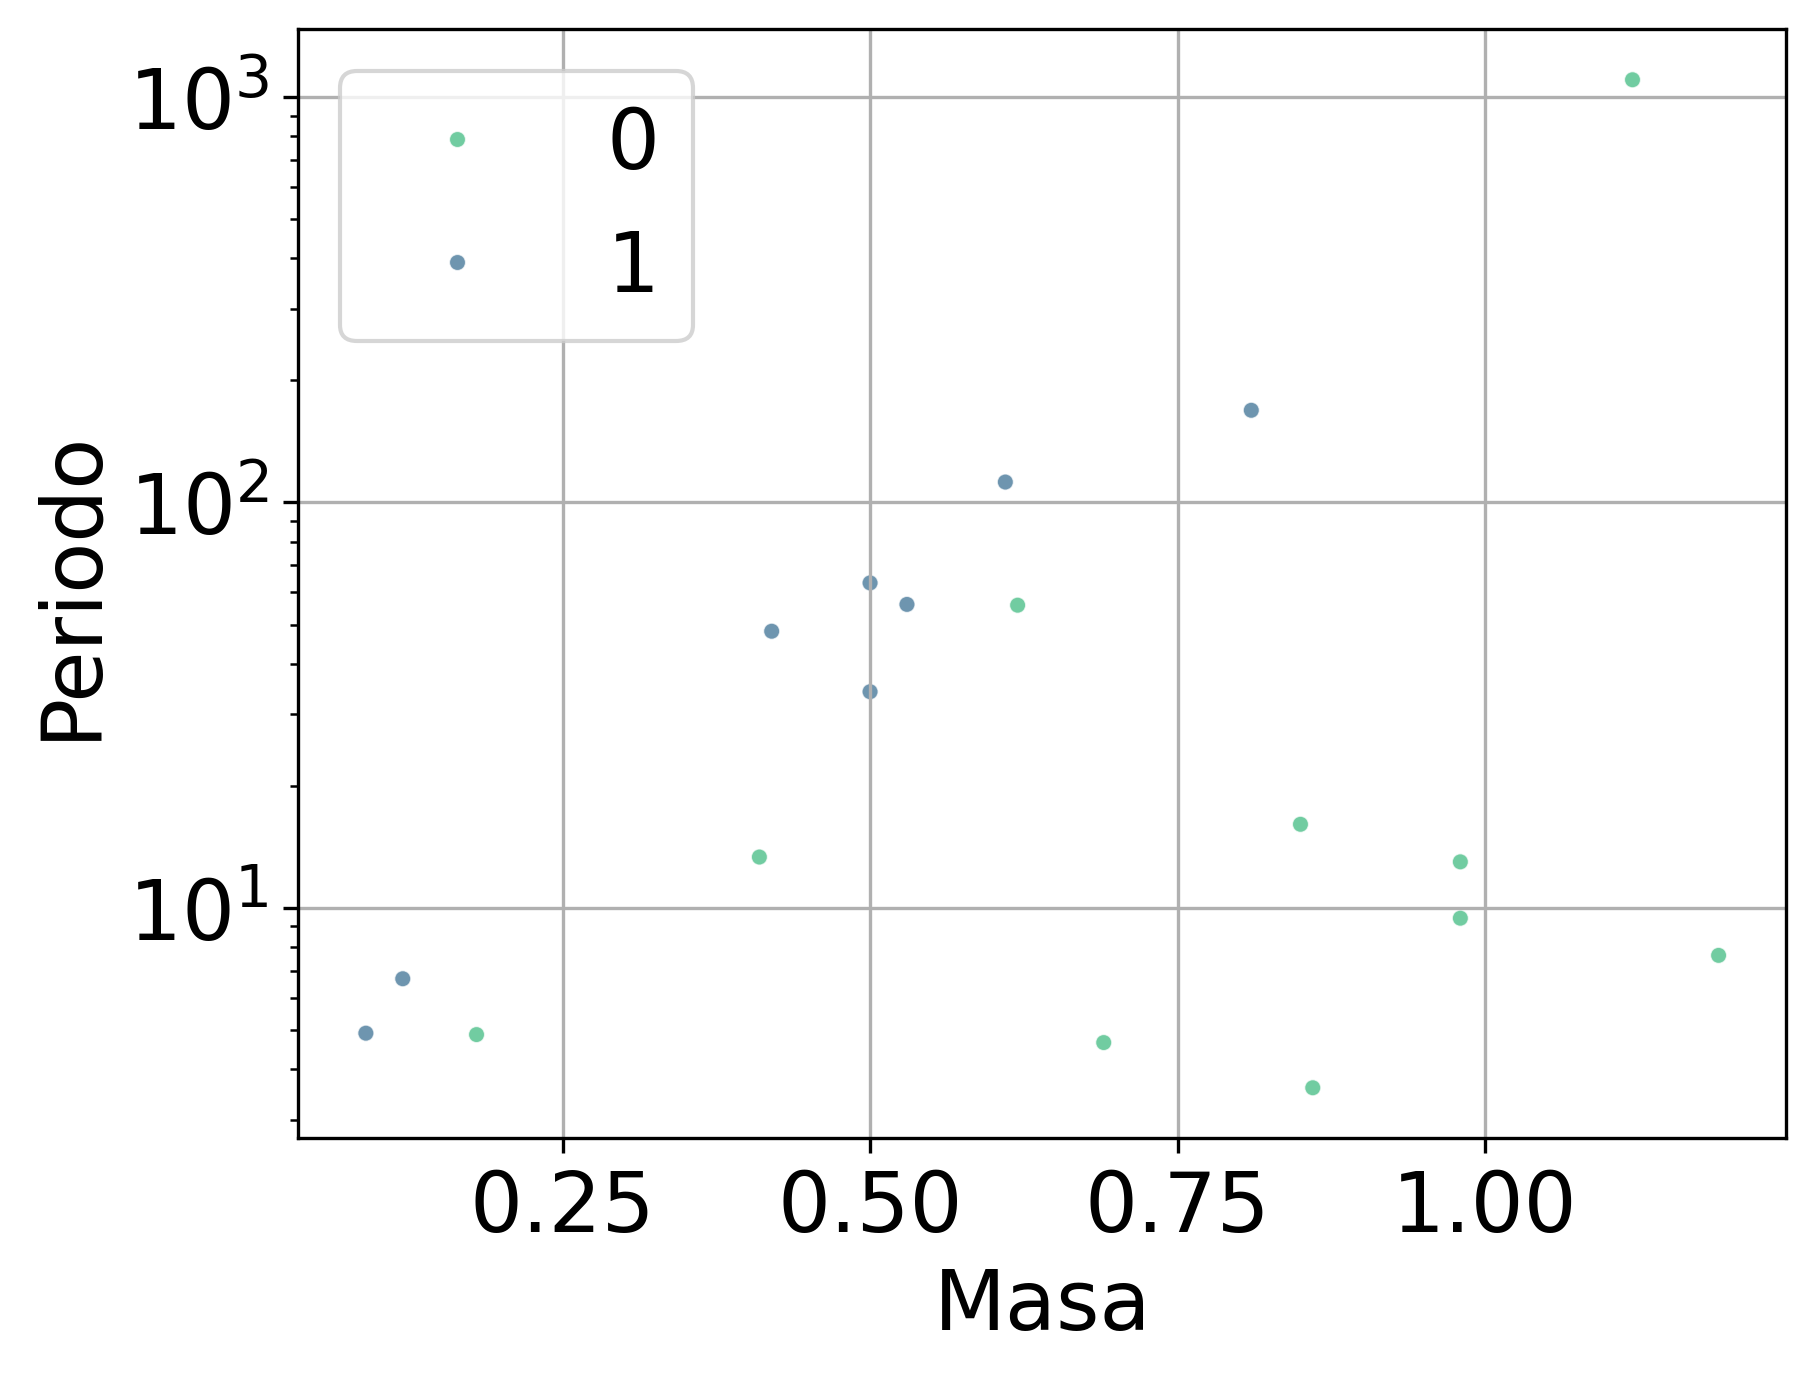

In [11]:
fig, ax = plt.subplots()
sns.scatterplot(data=LearningSet, x="S_MASS", y="P_PERIOD", hue="P_HABITABLE", s = 15, alpha = 0.7, palette = "viridis_r")
ax.set_yscale("log")
ax.set_xlabel('Masa')
ax.set_ylabel('Periodo')
ax.legend()
ax.grid()
plt.show()

**Antes de entrenar un modelo, te parece que las clases se separan fácilmente o no? Explique**

**Respuesta:** Podemos trazar una diagonal en el gráfico y se pueden separar bien los datos en dos.


### Elijamos el set de entrenamiento y prueba

Para definir los sets de etrenamiento y prueba, haremos una división *manual*

Definimos que las primeras 13 filas del dataframe será el conjunto de entrenamiento y los últimos 5, el conjunto de prueba

> En un problema real, usualmente preferimos una división aleatoria o validación cruzada.


Usaremos .iloc para acceder a los índices del dataframe

In [12]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [13]:
TrainSet =  LearningSet.iloc[:13,:]

TestSet = LearningSet.iloc[13:,:]

In [14]:
TrainSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [15]:
TestSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


También necesitamos definir para cada conjunto las características (features) y los objetivos (targets)

In [16]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento

Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features  conjunto de entrenamiento

In [17]:
Xtrain.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='object')

In [18]:
ytrain = TrainSet.P_HABITABLE #target conjunto prueba

ytest = TestSet.P_HABITABLE  #target conjunto prueba

In [19]:
Xtest

,S_MASS,P_PERIOD,P_DISTANCE
13,0.62,55.80600,0.260000
14,0.41,13.35200,0.087613
15,0.50,63.33627,0.268885
16,0.98,9.43415,0.088100
17,0.42,48.13450,0.195336


In [20]:
ytrain

,P_HABITABLE
0,0
1,0
2,0
3,1
4,0
5,1
6,0
7,1
8,0
9,1


### Entrenamos el modelo
Nota: En los árboles de decisión de scikit-learn, las características (o variables) se reorganizan aleatoriamente cada vez que se realiza una división para decidir cómo separar los datos. Esto significa que, incluso si se usa el mismo conjunto de datos de entrenamiento, la mejor forma de dividir los datos puede cambiar entre diferentes ejecuciones del modelo. Esta variación ocurre cuando varias divisiones posibles ofrecen la misma mejora en el criterio de evaluación (por ejemplo, reducir la impureza del nodo). En estos casos, el algoritmo puede elegir diferentes divisiones como "mejores" en diferentes ejecuciones debido al orden aleatorio en que se evalúan las características.

Para asegurar que los resultados del entrenamiento sean consistentes y reproducibles (es decir, que se obtenga el mismo árbol de decisión cada vez que se entrene con los mismos datos), es necesario fijar el parámetro random_state. Esto establece una semilla para el generador de números aleatorios utilizado por el algoritmo, garantizando que la permutación de las características sea la misma en cada ejecución y, por lo tanto, el resultado del modelo también sea el mismo.

In [21]:
from sklearn.tree import DecisionTreeClassifier #modelo de árbol de decisión


In [22]:
model = DecisionTreeClassifier(random_state = 3) #Inicializamos el modelo con sus parámetros, random_state es la semilla

model.fit(Xtrain, ytrain) #En una línea, construimos el modelo, entrenamos el modelo con los datos de entrenamiento

DecisionTreeClassifier(random_state=3)

### Podemos visualizar el árbol (visualización "pro")

debe instalar la libreria [`pydotplus`](https://pypi.org/project/pydotplus/)  y [`graphviz`](https://pypi.org/project/graphviz/)

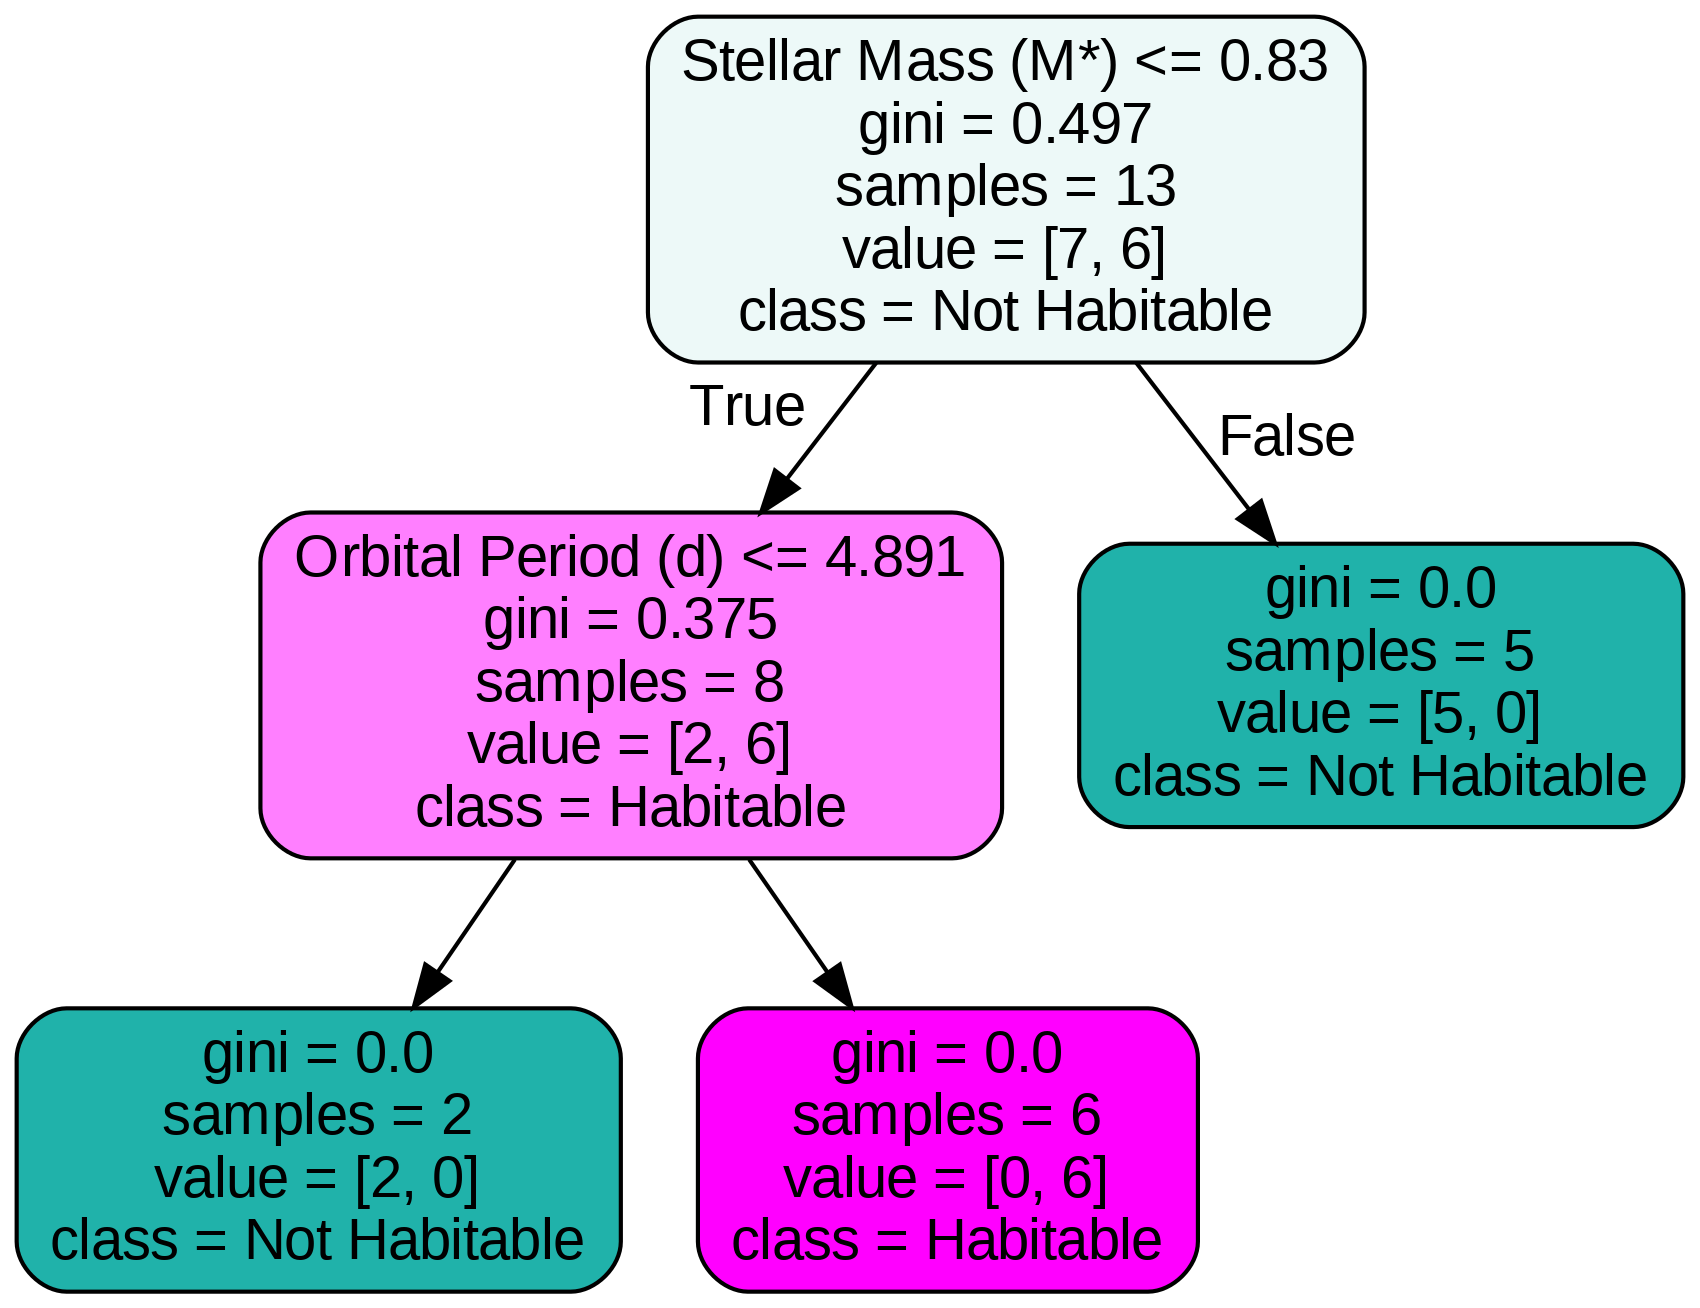

In [23]:
dot_data = StringIO()
export_graphviz(
            model,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]

        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

Image(graph.create_png())

#Image(graph.write_png('Graph.png'))

### Visualización de sklearn

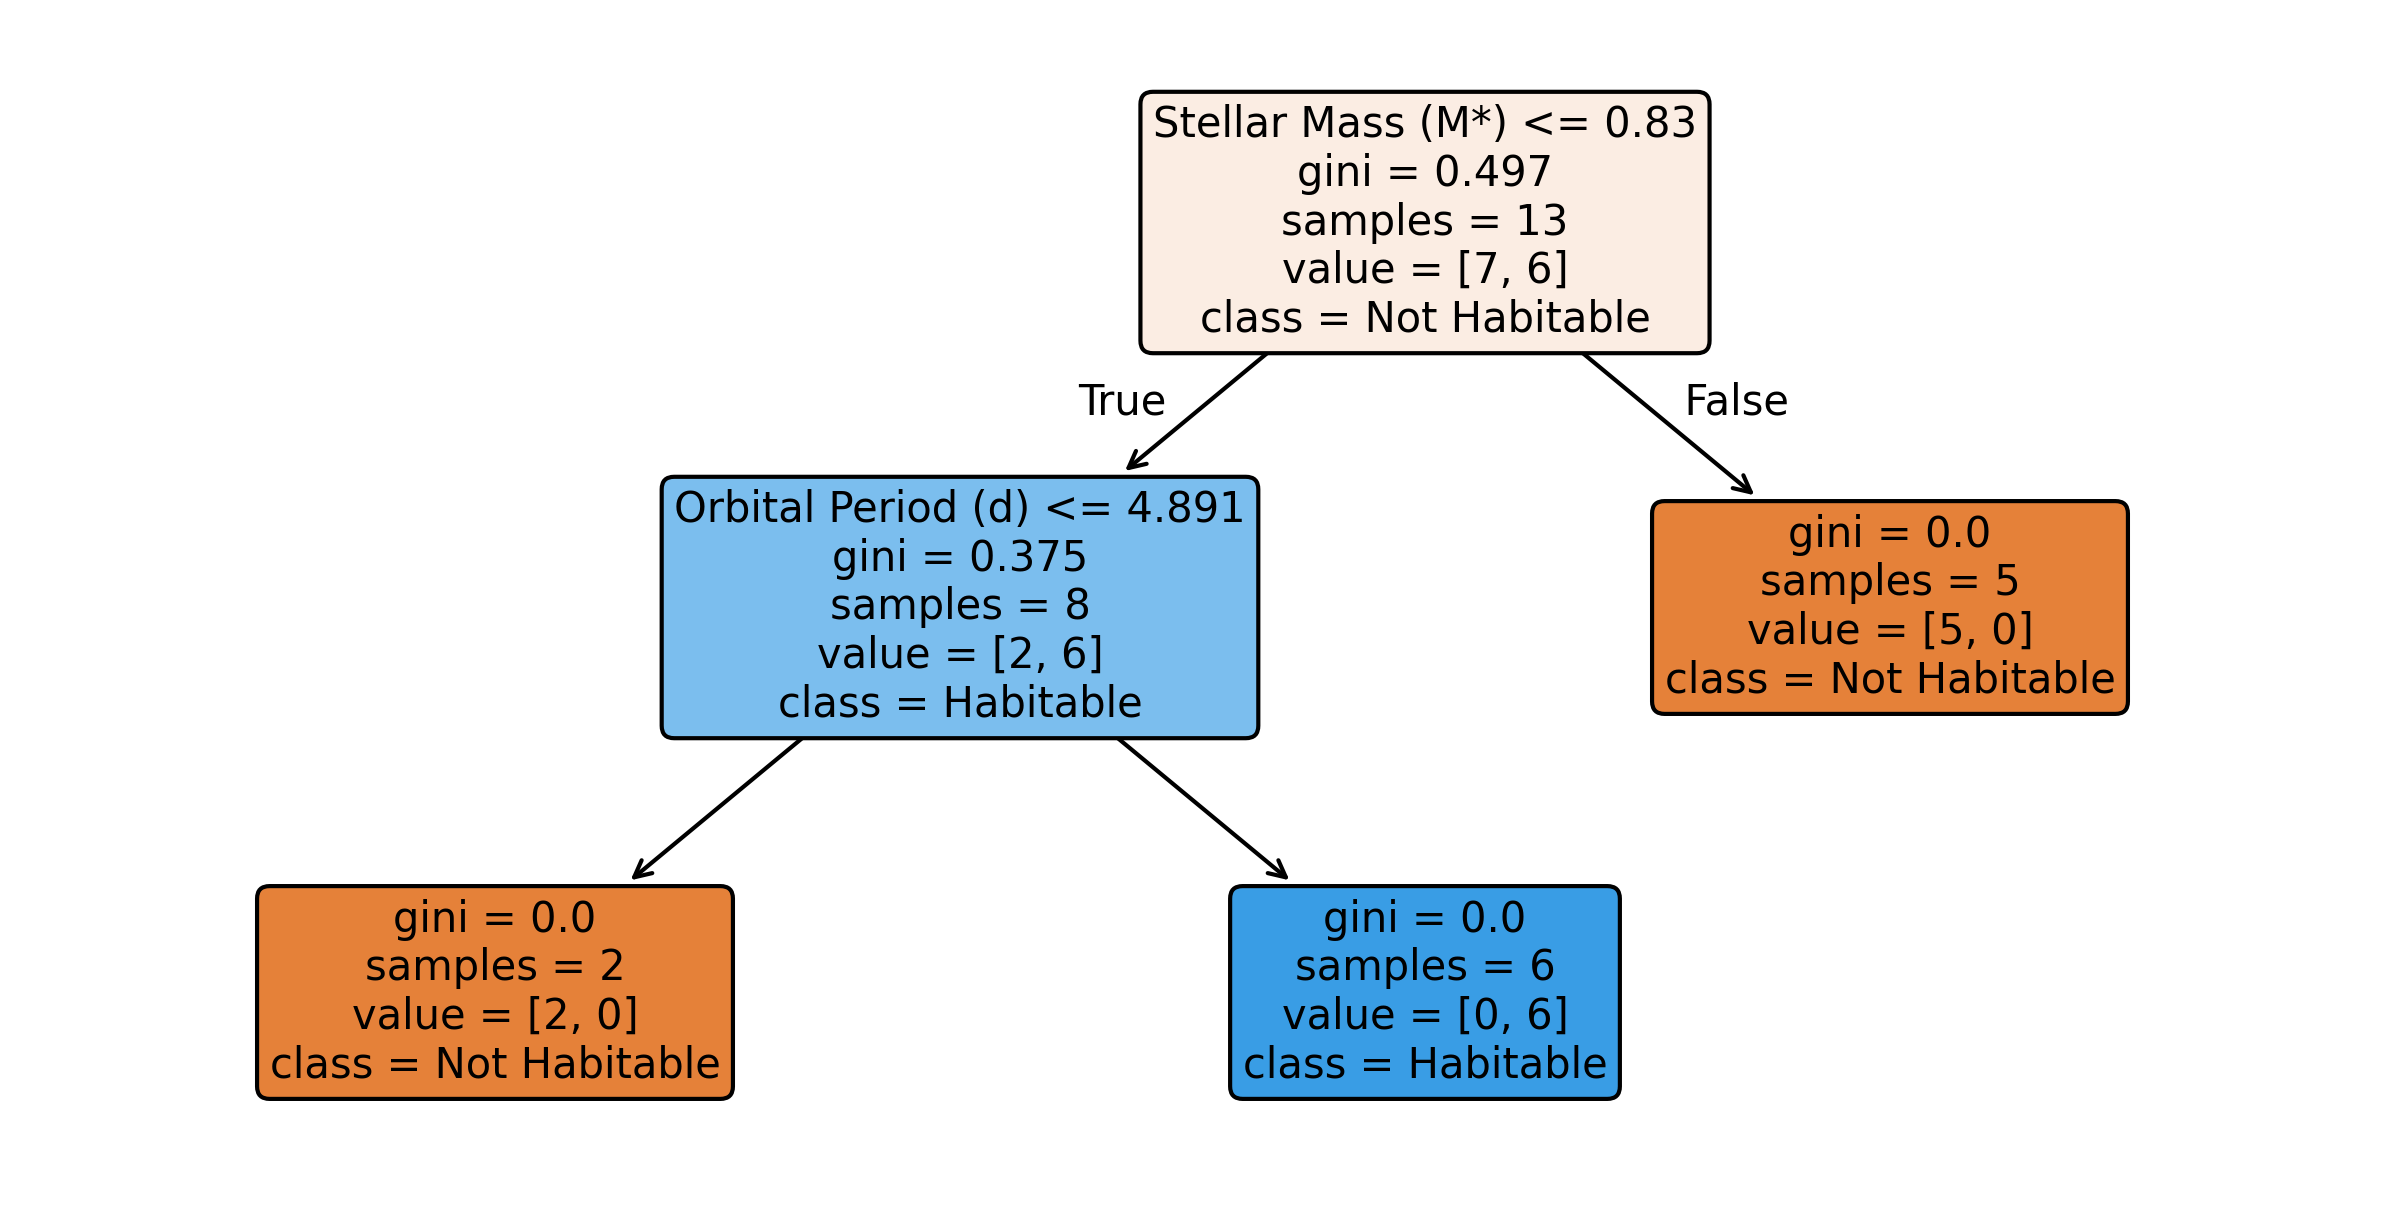

In [24]:
from sklearn import tree

plt.figure(figsize=(10,5))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(model,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

### También podemos visualizar las decisiones del clasificador. El color de sombreado predice la etiqueta, y el color de los puntos marca la etiqueta real:

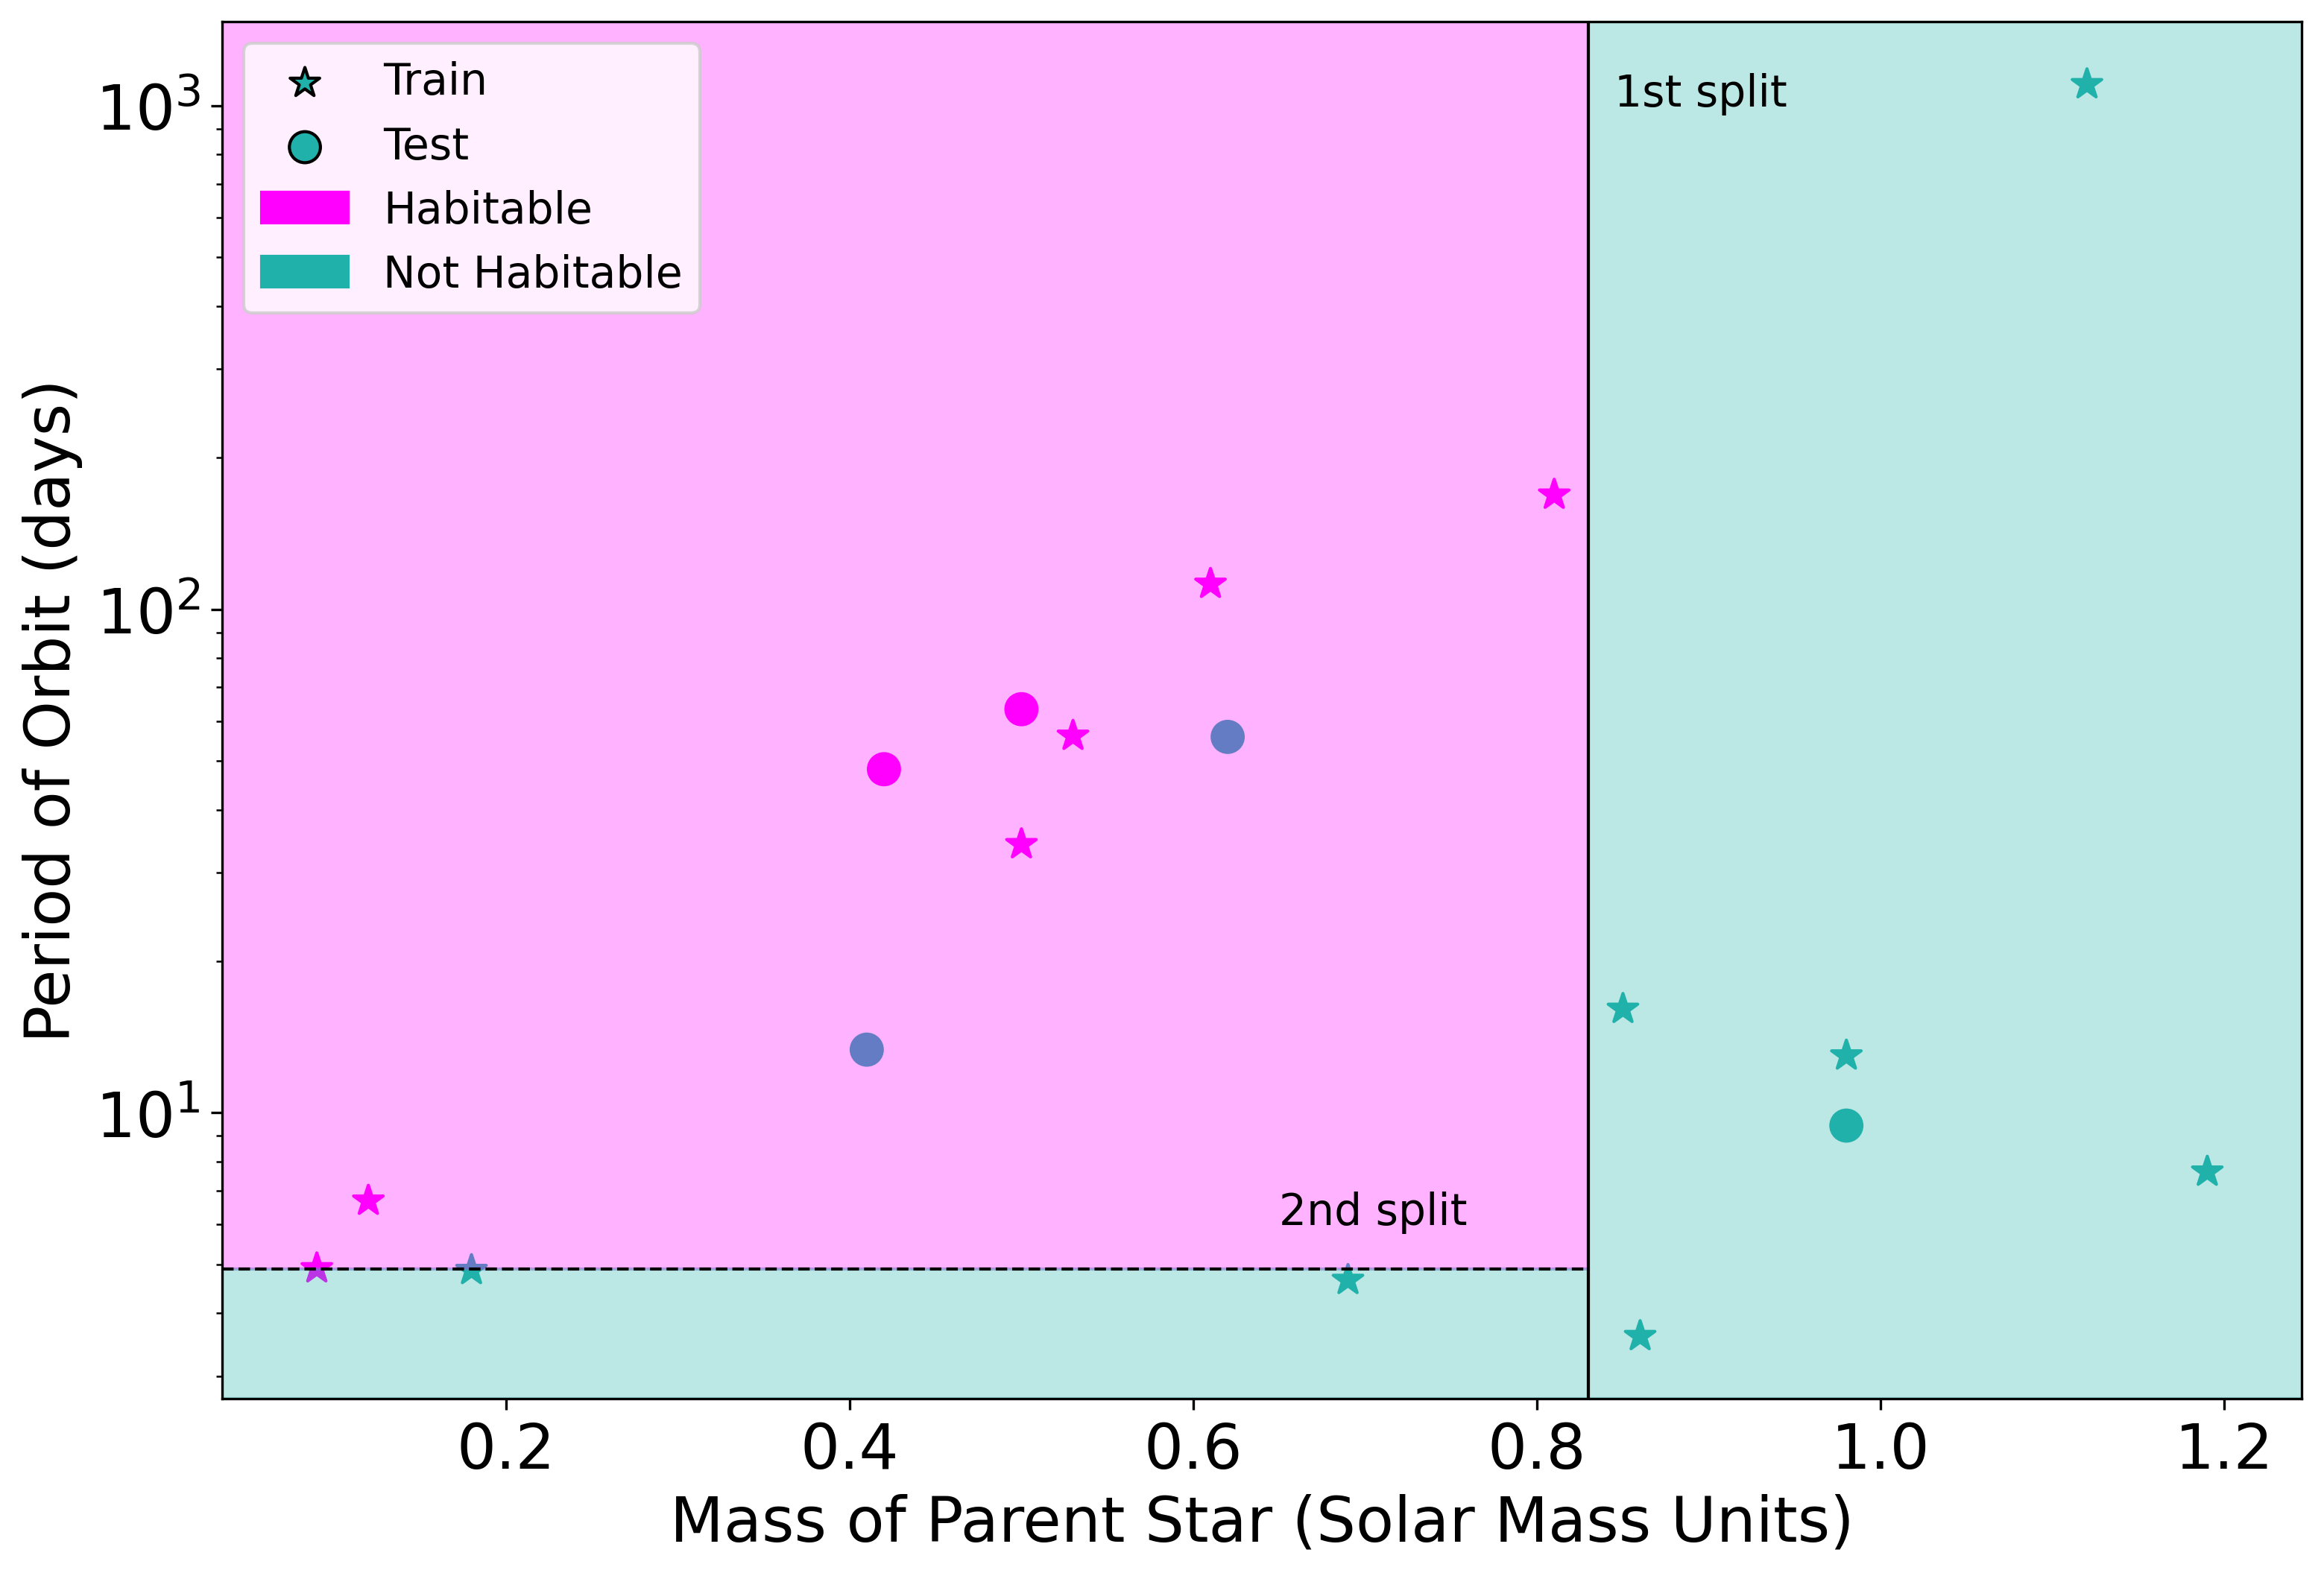

In [25]:
plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',\
            c = TrainSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',\
            c = TestSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')

plt.xlabel('Mass of Parent Star (Solar Mass Units)')

plt.ylabel('Period of Orbit (days)');

#splits del gráfico

plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)

plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')

magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1],
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);


### Pregunta
    
- ¿Cuál es el porcentaje de clasificaciones correctas en el set de entrenamiento?  Y en el set de prueba?


A este porcentaje de clasificaciones correctas lo llamaremos **accuracy**

### usando la métricas de sklearn, podemos encontrar el accuracy


In [26]:
import sklearn.metrics as metrics


In [27]:
ypred = model.predict(Xtest) #generamos etiquetas de predicción en el set de prueba

In [28]:
ypred

array([1, 1, 1, 0, 1])

Accuracy es una métrica usual para evaluar modelos de clasificación, y hay una función en el módulo `sklearn.metrics`. Tenemos que comparar los resultados de la predicción `ypred` con los valores reales `ytest`

In [29]:
metrics.accuracy_score(ytest, ypred) #test score

0.6

también podemos encontrar el accuracy de los datos de entrenamiento, generando predicciones para los `Xtrain` y comparando con el `ytrain`

In [30]:
metrics.accuracy_score(ytrain, model.predict(Xtrain)) #train score

1.0

### Preguntas de interpretación
1. ¿El árbol clasifica perfectamente el conjunto de entrenamiento?

**Respuesta**: Según los valores de métrica, apunta a que si.

2. ¿Qué ocurre en el conjunto de prueba?

**Respuesta:** Se usa para probar la eficiencia del modelo.


3. ¿Qué variable aparece en la raíz del árbol?

**Respuesta:** La masa estelar.

4. ¿Te parece que este árbol es simple o ya es relativamente profundo para un dataset tan pequeño?

**Respuesta:** Parece simple ya que trabaja con la amsa estelar y el periodo orbital, parámetros que son insuficientes para la clasificación de habitabilidad.


In [31]:
# -------------------------------------------------------------------------------------------------------------------------------------------------------------

### Ahora elegiremos un set de entrenamiento distinto. Las 5 primeras filas serán de prueba y el resto será para el entrenamiento

In [32]:
# los primeros 5 de prueba, el resto de entrenamiento
TrainSet2 = LearningSet.iloc[5:,:]

TestSet2 = LearningSet.iloc[:5,:]

### Repita el proceso anterior

1. Defina los dataframes de características y la serie de categorías para entrenamiento y prueba: `Xtrain2`, `Xtest2`, `ytrain2`, `ytest2`
2. inicialice el modelo de árbol de decisión para clasificación (defina semilla `random_state=3`
3. ajuste el modelo a los datos de entrenamiento
4. visualice el árbol
5. calcule accuracy para entrenamiento y prueba

In [33]:
Xtrain2 = TrainSet2.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento

Xtest2 = TestSet2.drop(['P_NAME','P_HABITABLE'],axis=1) #features  conjunto de entrenamiento

In [34]:
ytrain2 = TrainSet2.P_HABITABLE #target conjunto prueba

ytest2 = TestSet2.P_HABITABLE  #target conjunto prueba

In [35]:
# 3. Ajuste modelo

model2 = DecisionTreeClassifier(random_state = 3) #Inicializamos el modelo con sus parámetros, random_state es la semilla

model2.fit(Xtrain2, ytrain2)

DecisionTreeClassifier(random_state=3)

In [36]:
ypred2 = model2.predict(Xtest2)

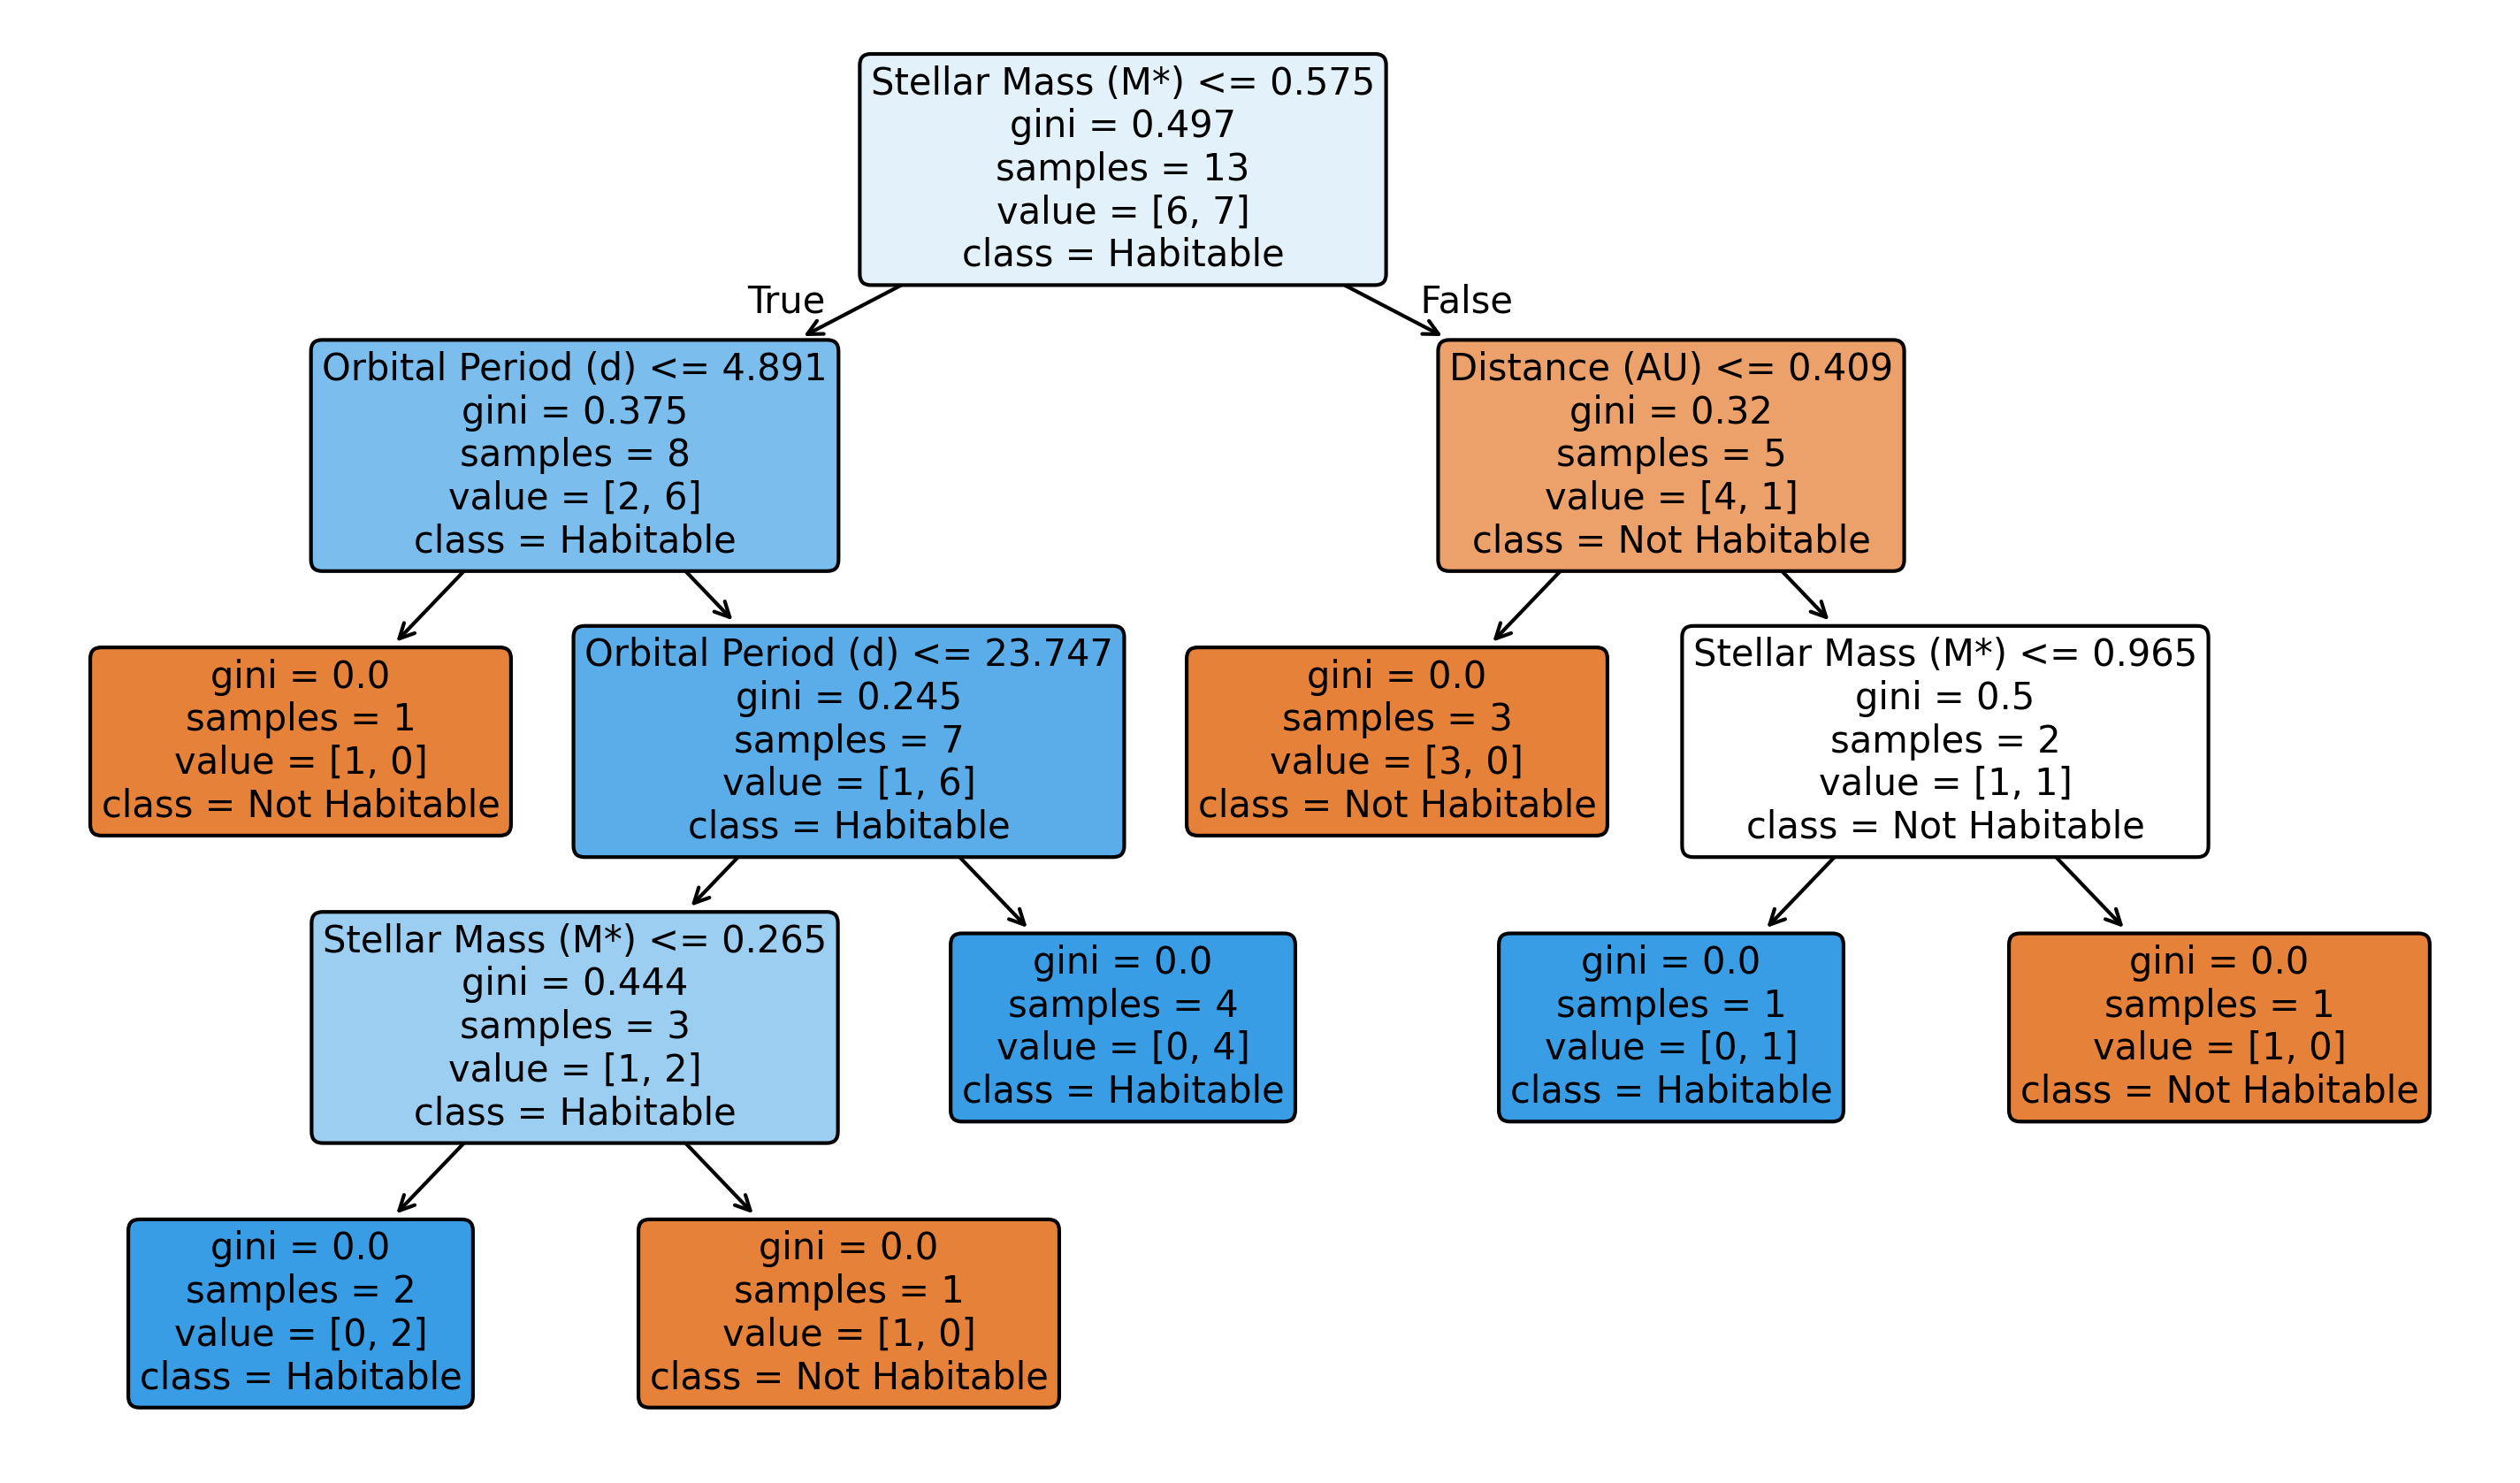

In [37]:
# 4. Visualice árbol
plt.figure(figsize=(12,7))
tree.plot_tree(model2,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

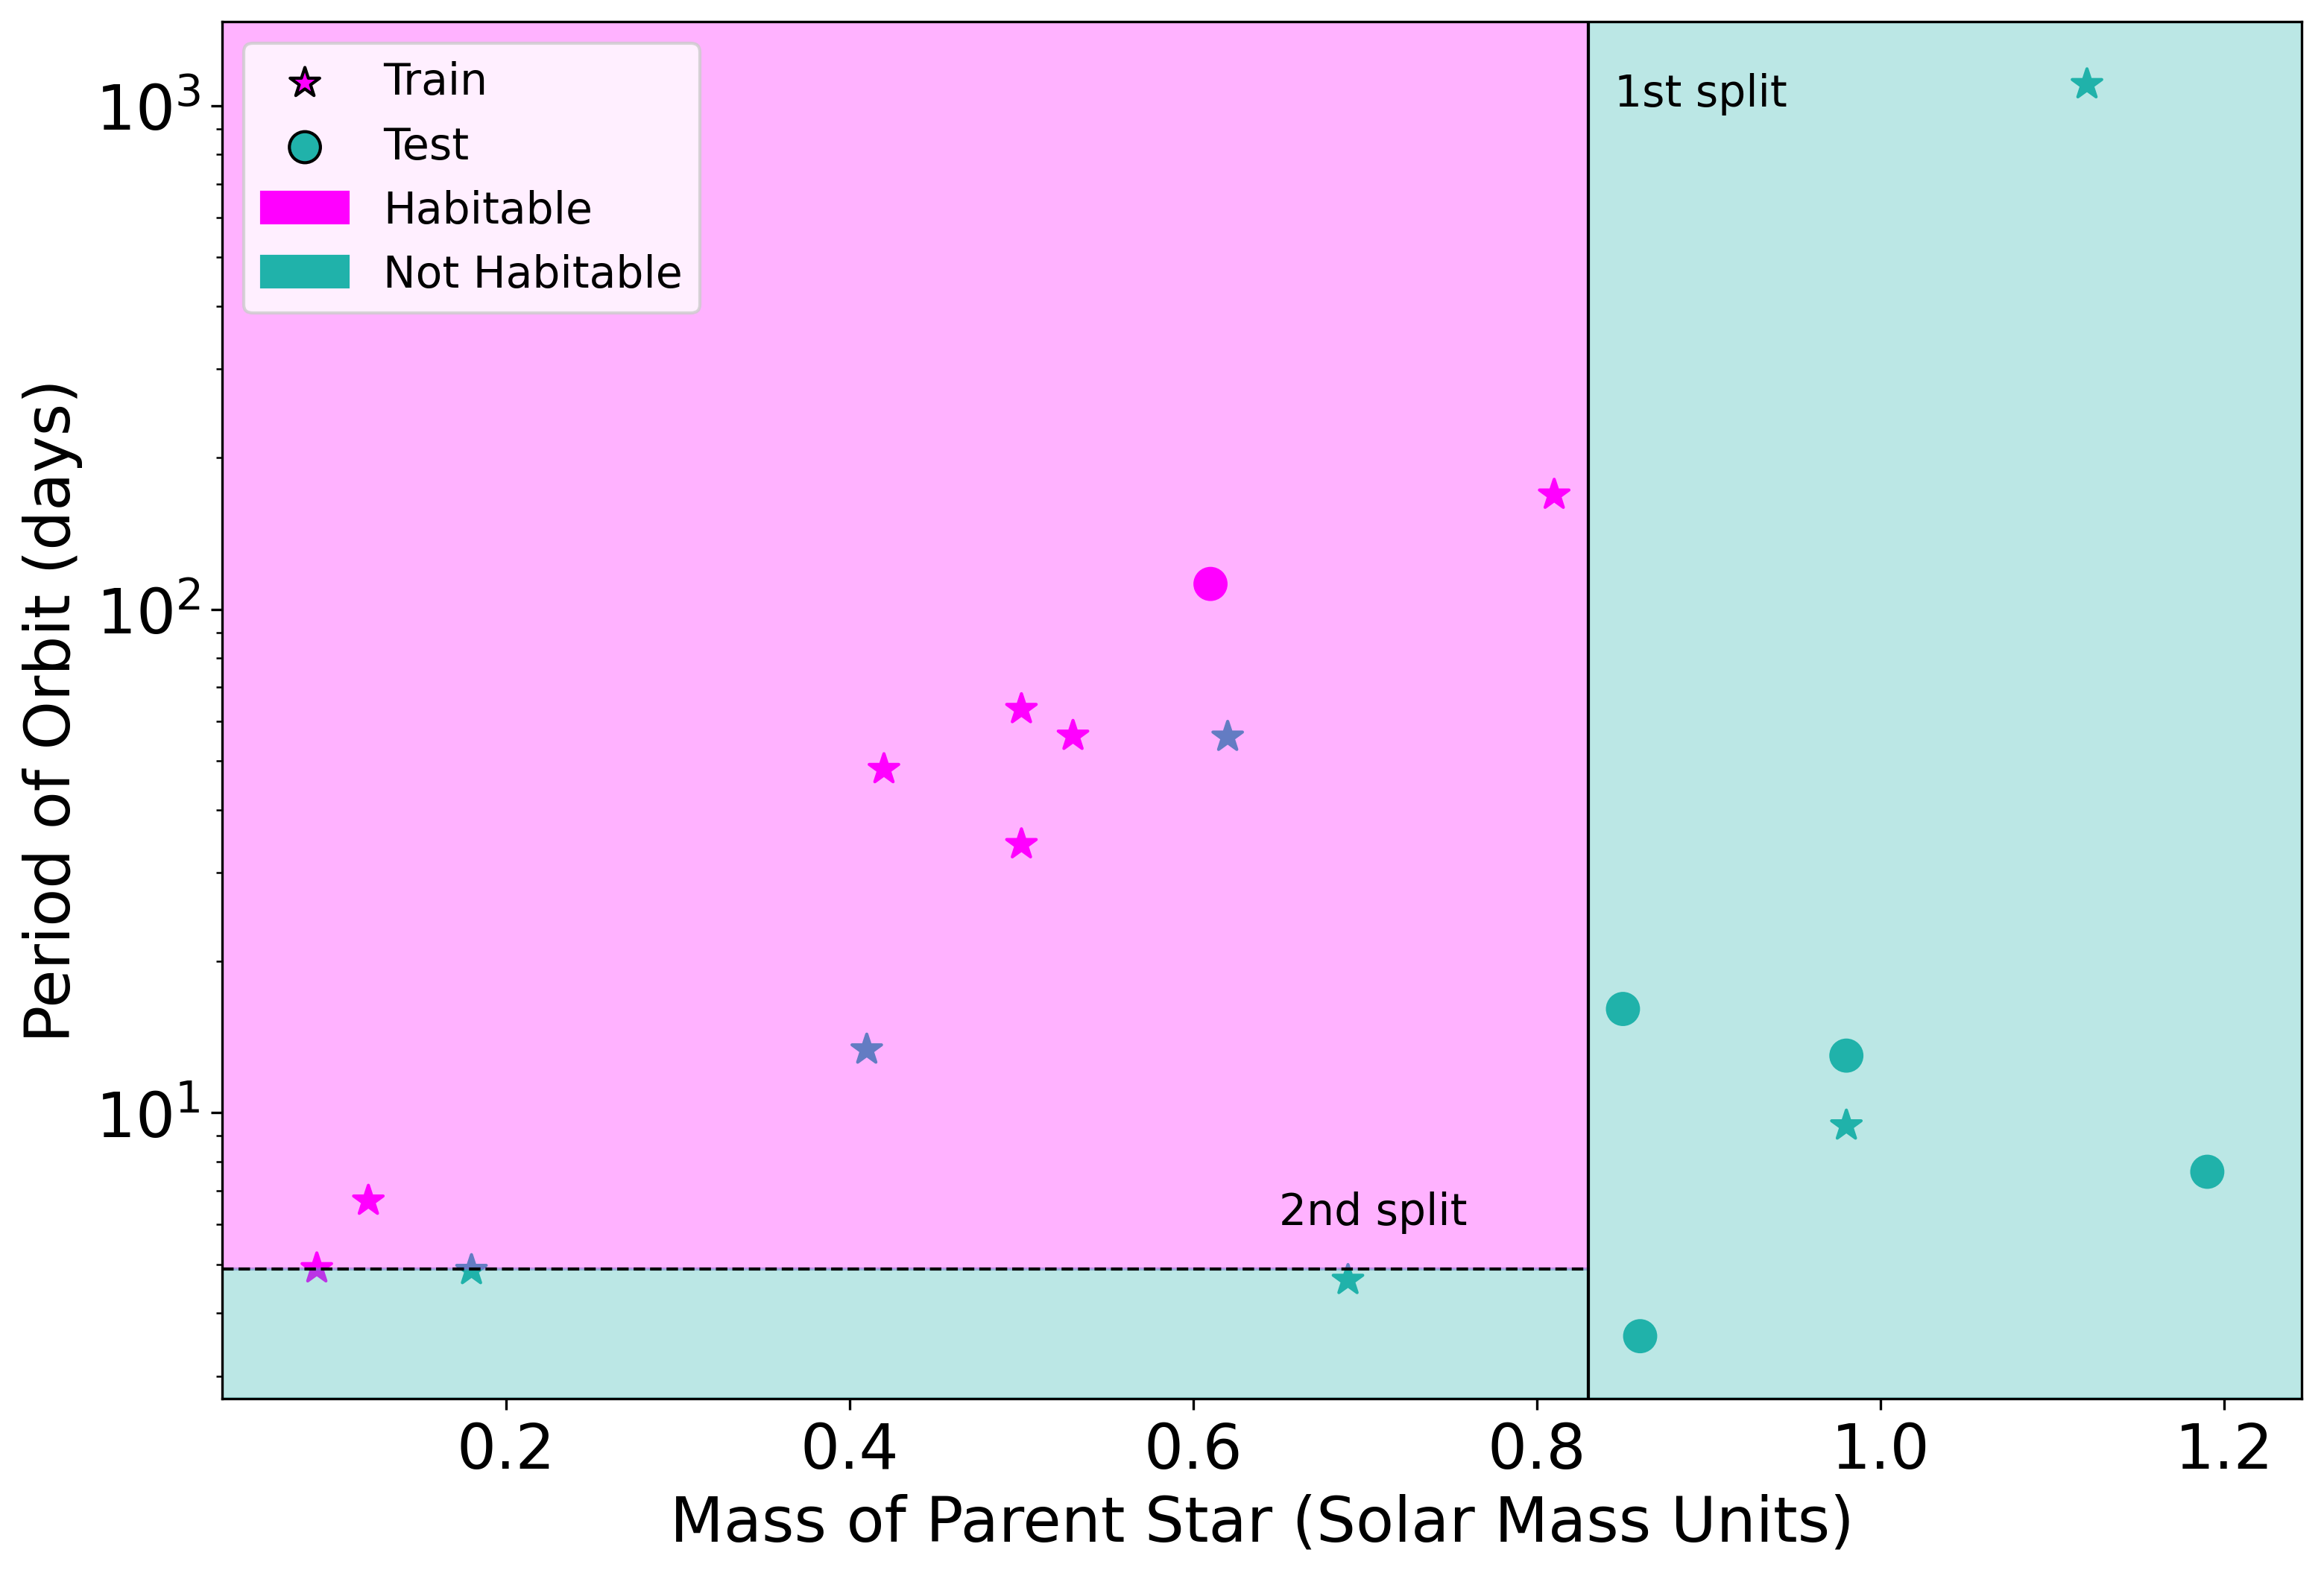

In [38]:
# 5. Calcule accuracy para entrenamiento y prueba

plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet2['S_MASS'], TrainSet2['P_PERIOD'], marker = '*',\
            c = TrainSet2['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet2['S_MASS'], TestSet2['P_PERIOD'], marker = 'o',\
            c = TestSet2['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')

plt.xlabel('Mass of Parent Star (Solar Mass Units)')

plt.ylabel('Period of Orbit (days)');

#splits del gráfico

plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)

plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')

magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1],
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);

In [39]:
# Accuracy para el segundo modelo conjunto prueba
metrics.accuracy_score(ytest2, ypred2)

1.0

In [40]:
model2.score(Xtrain2, ytrain2)

1.0

### Preguntas:

- Compare el árbol de decisión inicial vs el obtenido ahora. Nota alguna diferencia?

**Respuesta:** Cambiaron los valores en el gráfico de test y entrenamiento, aunque sigue siendo la misma proporción.

- ¿Cuál es el accuracy (porcentaje de clasificaciones correctas) en el conjunto de entrenamiento?

**Respuesta:** 1

- ¿Y en el conjunto de prueba?

**Respuesta:** 1

- Si ahora el resultado es mejor, ¿significa automáticamente que este árbol es “mejor” en general?

**Respuesta:** Aparentemente si, porque logró clasificar mejor


### Conclusiones

- Que puede concluir respecto a al ejercicio?

**Respuesta:** Cambiar los parámetros de sets de entrenamiento y prueba puede complejizar o simplificar los árboles de decisiones. A su vez la clasificación del modelo pareciera mantenerse.

- Cambian los resultados dependiendo del set de datos que utilizamos?

**Respuesta:** No cambian, solo los valores presentados como entrenamiento y prueba.

- ¿Sería la Tierra clasificada como habitable por alguno de estos árboles?

**Respuesta:** No sería clasificado como habitable, principalmente por el primer filtro que es de masa estelar.

In [41]:
# -------------------------------------------------------------------------------------------------------------------------------------------------------------

## k-Nearest Neighbors

Aplicaremos ahora kNN al mismo problema.

>kNN clasifica según las etiquetas de los `k` vecinos más cercanos, es un método basado en distancia, por eso la **escala** de las variables sí importa.




In [42]:
from sklearn import neighbors
import sklearn

Para el mismo set de datos de habitabilidad de planetas

In [43]:
Xtrain

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408
5,0.09,4.910000,0.025200
6,0.69,4.655411,0.048086
7,0.12,6.689000,0.035000
8,1.12,1103.000000,2.180981
9,0.81,168.811170,0.557107


### "Entrenamos" el modelo
Es un algoritmo sencillo basado en la idea de distancia: buscamos los k (un número entero) objetos que están más cerca del que queremos clasificar, y tomamos la votación de la mayoría entre las k clases de los k vecinos.

kNN es un algoritmo basado en instancias (también llamado **"lazy learning"**), sigue necesitando saber con qué datos va a comparar para hacer predicciones futuras. El método fit le dice al algoritmo con qué datos va a trabajar.

El método fit en kNN no ajusta parámetros del modelo como en otros algoritmos.
Simplemente almacena los datos de entrenamiento para su uso durante la predicción.
Durante la predicción, el algoritmo calcula las distancias entre el nuevo punto y los puntos de entrenamiento almacenados para encontrar los k vecinos más cercanos y decidir la clase del nuevo punto basado en una votación mayoritaria.
En esencia, el proceso de "ajuste" en kNN es solo la configuración de los datos de referencia para comparaciones futuras, no un ajuste de parámetros basado en optimización.









In [44]:
model = neighbors.KNeighborsClassifier(n_neighbors = 3) #elegimos los 3 vecinos más cercanos

In [45]:
model

KNeighborsClassifier(n_neighbors=3)

#### Para propósitos de visualización, usemos solo las dos primeras características para construir el modelo.

In [46]:
Xtrain.iloc[:,:2]

,S_MASS,P_PERIOD
0,0.86,3.601472
1,0.85,16.080661
2,1.19,7.638460
3,0.61,112.305300
4,0.98,12.992073
5,0.09,4.910000
6,0.69,4.655411
7,0.12,6.689000
8,1.12,1103.000000
9,0.81,168.811170


#### Se construye el modelo aplicando el método .fit al conjunto de entrenamiento. Luego, predice las etiquetas para el conjunto de prueba.

In [47]:
model.fit(Xtrain.iloc[:,:2],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(Xtest.iloc[:,:2]) #esto ajsta el modelo en los datos de prueba

In [48]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

#### Calculando accuracy en los sets de entrenamiento y prueba

In [49]:
print(metrics.accuracy_score(ytrain, model.predict(Xtrain.iloc[:,:2]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento

print(metrics.accuracy_score(ytest, model.predict(Xtest.iloc[:,:2]))) #mismo que anterior, pero para set de prueba

0.6923076923076923
0.8


#### Después de ajustar y la predicción, podemos ver los k neighbors que encontró el modelo en el conjunto de prueba

In [50]:
model.kneighbors(Xtest.iloc[:,:2]) #el primer elemento es la distancia, el segundo los índices de cada vecinos

(array([[ 0.26575741, 21.66422235, 39.72600482],
        [ 0.67412717,  2.76390862,  5.76653597],
        [ 7.28027781, 29.19416   , 47.25690512],
        [ 1.807928  ,  2.87670841,  3.5579225 ],
        [ 7.9223177 , 13.99261869, 32.05672308]]),
 array([[11, 10,  1],
        [ 4,  1,  2],
        [11, 10,  1],
        [ 2,  7,  4],
        [11, 10,  1]]))

### Visualizando los resultados

USamos la distancia del tercer vecino como el radio del círculo que encierra vecinos


In [51]:
for i in range(len(TestSet)): # para cada elemento del set de prueba

    print(model.kneighbors(Xtest.iloc[:,:2])[0][i,2]) # muestra el tercer elemento del vector de distancia

39.7260048163029
5.766535965914376
47.2569051246575
3.5579225
32.05672308015779


El siguiente código dibuja un círculo incluyendo a los 3 vecinos más cercanos para cada punto

### Nota: Para la aplicación real (no la visualización), debiéramos usar todas las features disponibles

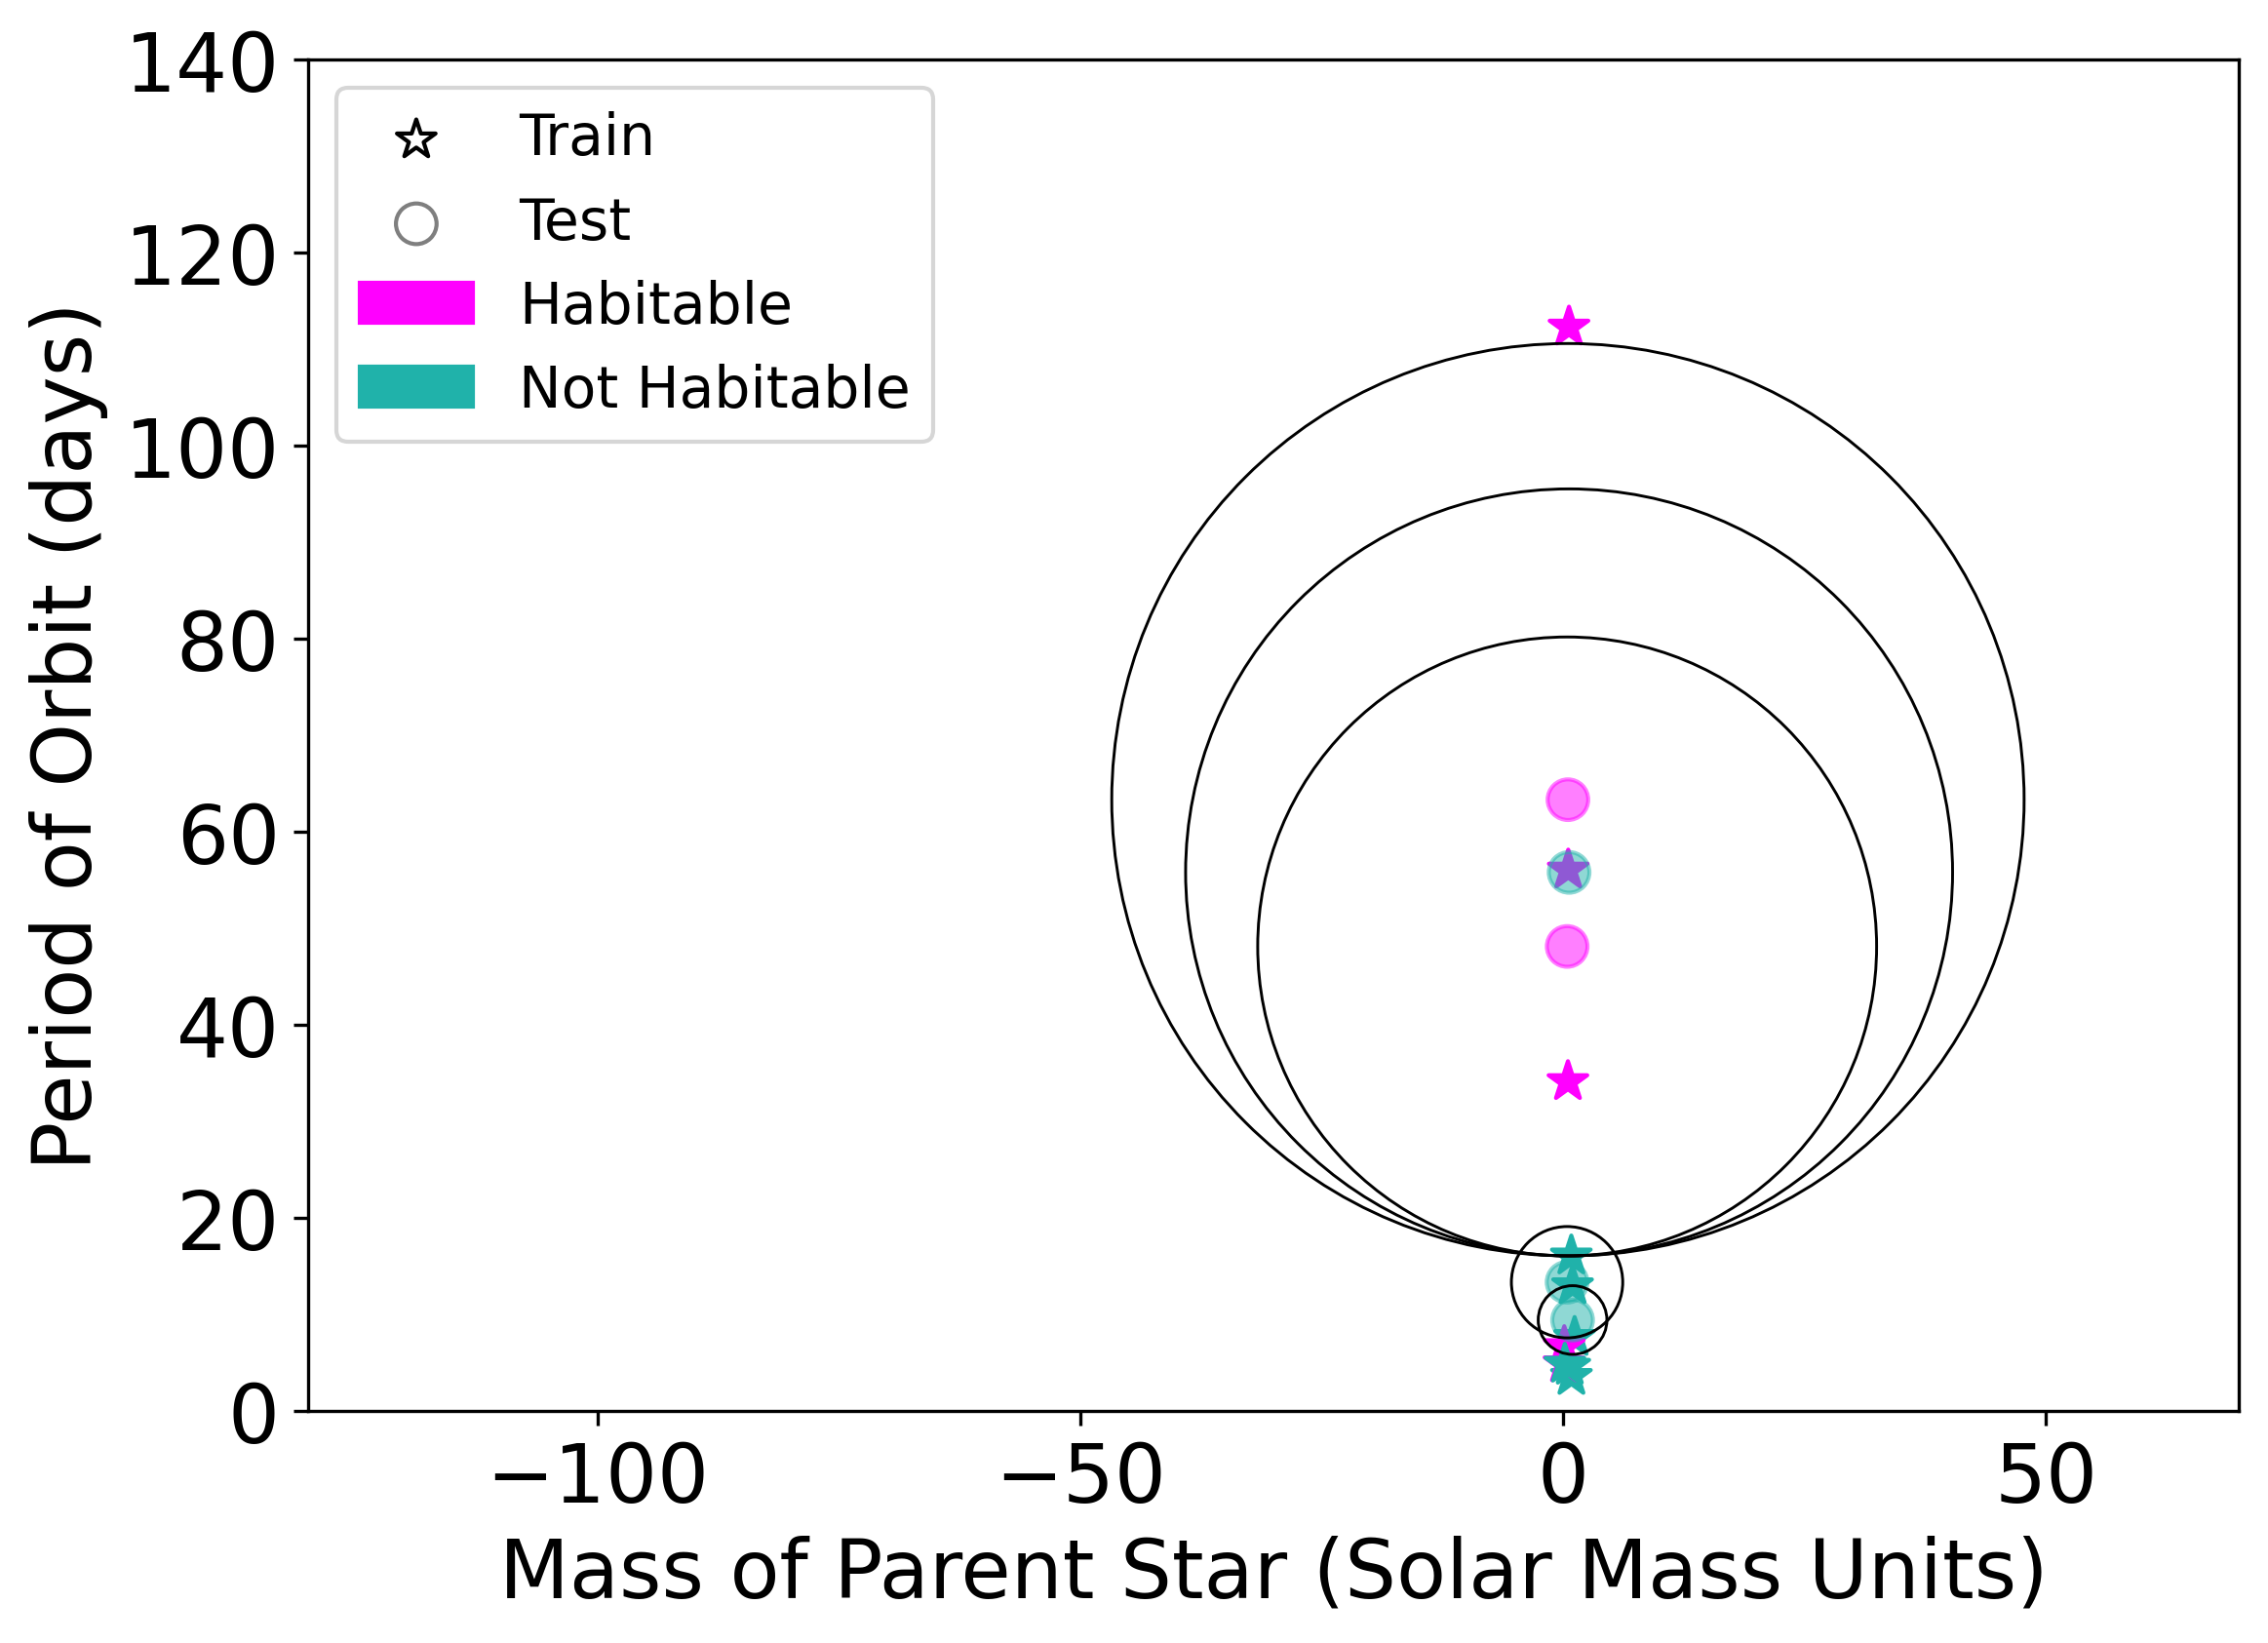

In [52]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap)

#a.set_facecolor('none')


a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5)

#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),model.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)

plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

plt.xlim(-130,70)
plt.ylim(0,140)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#plt.savefig('HabPlanetsKNN2features.png', dpi = 300)

### Nota algo particular en el gráfico?

 **Si una dimensión tiene un rango mucho mayor que las otras, dominará el proceso de decisión. Este problema se puede solucionar mediante el <b>escalado</b>. El escalado es un paso de preprocesamiento muy importante para la mayoría de los algoritmos de aprendizaje automático.**



Algunos ejemplos de algoritmos de Scaler [aquí](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html).

Usaremos [`RobustScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html), que se comporta mejor con outliers que la versión estándar, ya que escala de acuerdo a percentiles. Específicamente, usa la mediana (percentil 50) y el rango intercuartílico (IQR = Q3 - Q1), lo cual lo hace menos sensible a valores extremos


In [53]:
scaler = sklearn.preprocessing.RobustScaler() #inicializamos el Scaler

#### Importante!!

Debemos ajustar el escalador **sólo con los datos de entrenamiento**. Esto se hace porque **el modelo no debe tener acceso a los datos de prueba durante el entrenamiento**. Si usamos los datos de prueba para ajustar el escalador, estaríamos filtrando información del futuro, lo que se conoce como data leakage.

Esto puede llevar a dos problemas: por un lado, el modelo podría parecer más preciso de lo que realmente es, y por otro, podría aprender patrones que no se generalizan bien a datos nuevos, lo que se traduce en sobreajuste.

Para evitar esto, primero se ajusta el escalador con los datos de entrenamiento (`fit`), y luego se usa ese mismo escalador para transformar tanto el entrenamiento como el test (`transform`).

In [54]:
scaler.fit(Xtrain) # importante: solo escalamos el set de entrenamiento

RobustScaler()

In [55]:
scaledXTrain = scaler.transform(Xtrain)

In [56]:
scaledXTrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

In [57]:
scaledXtest = scaler.transform(Xtest) #

In [58]:
scaler.inverse_transform #esto invierte el escalado si es necesario

<bound method RobustScaler.inverse_transform of RobustScaler()>

**Ahora, con los datos escalados, aplique el modelo de kNN inicializado anteriormente, genere las predicciones y genere la misma visualización que en el caso anterior**

In [59]:
scaledXTrain[:,:2]

array([[ 0.47222222, -0.18360363],
       [ 0.44444444,  0.06038761],
       [ 1.38888889, -0.10467304],
       [-0.22222222,  1.94175736],
       [ 0.80555556,  0.        ],
       [-1.66666667, -0.15801948],
       [ 0.        , -0.16299717],
       [-1.58333333, -0.12323674],
       [ 1.19444444, 21.311672  ],
       [ 0.33333333,  3.04655169],
       [-0.52777778,  0.41352236],
       [-0.44444444,  0.84198052],
       [-1.41666667, -0.15877753]])

In [60]:
model.fit(scaledXTrain[:,:2],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred2 = model.predict(scaledXtest[:,:2]) #esto ajsta el modelo en los datos de prueba

In [61]:
ytestpred2, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

In [62]:
print(metrics.accuracy_score(ytrain, model.predict(scaledXTrain[:,:2]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento

print(metrics.accuracy_score(ytest, model.predict(scaledXtest[:,:2]))) #mismo que anterior, pero para set de prueba

0.8461538461538461
0.8


In [63]:
model.kneighbors(scaledXtest[:,:2]) #el primer elemento es la distancia, el segundo los índices de cada vecinos

(array([[0.2500478 , 0.53900086, 1.00570768],
        [0.47721081, 0.66005572, 0.79614695],
        [0.16494121, 0.57079985, 1.00501058],
        [0.06956397, 0.35230123, 0.38378203],
        [0.34256727, 0.35245873, 1.07701084]]),
 array([[11, 10,  1],
        [10, 12,  6],
        [11, 10,  3],
        [ 4,  0,  1],
        [11, 10, 12]]))

In [64]:
for i in range(len(TestSet)): # para cada elemento del set de prueba

    print(model.kneighbors(scaledXtest[:,:2])[0][i,2]) # muestra el tercer elemento del vector de distancia

1.0057076822074733
0.7961469534072081
1.0050105812138872
0.3837820313273946
1.0770108415685602


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


Text(0, 0.5, 'Period of Orbit (days)')

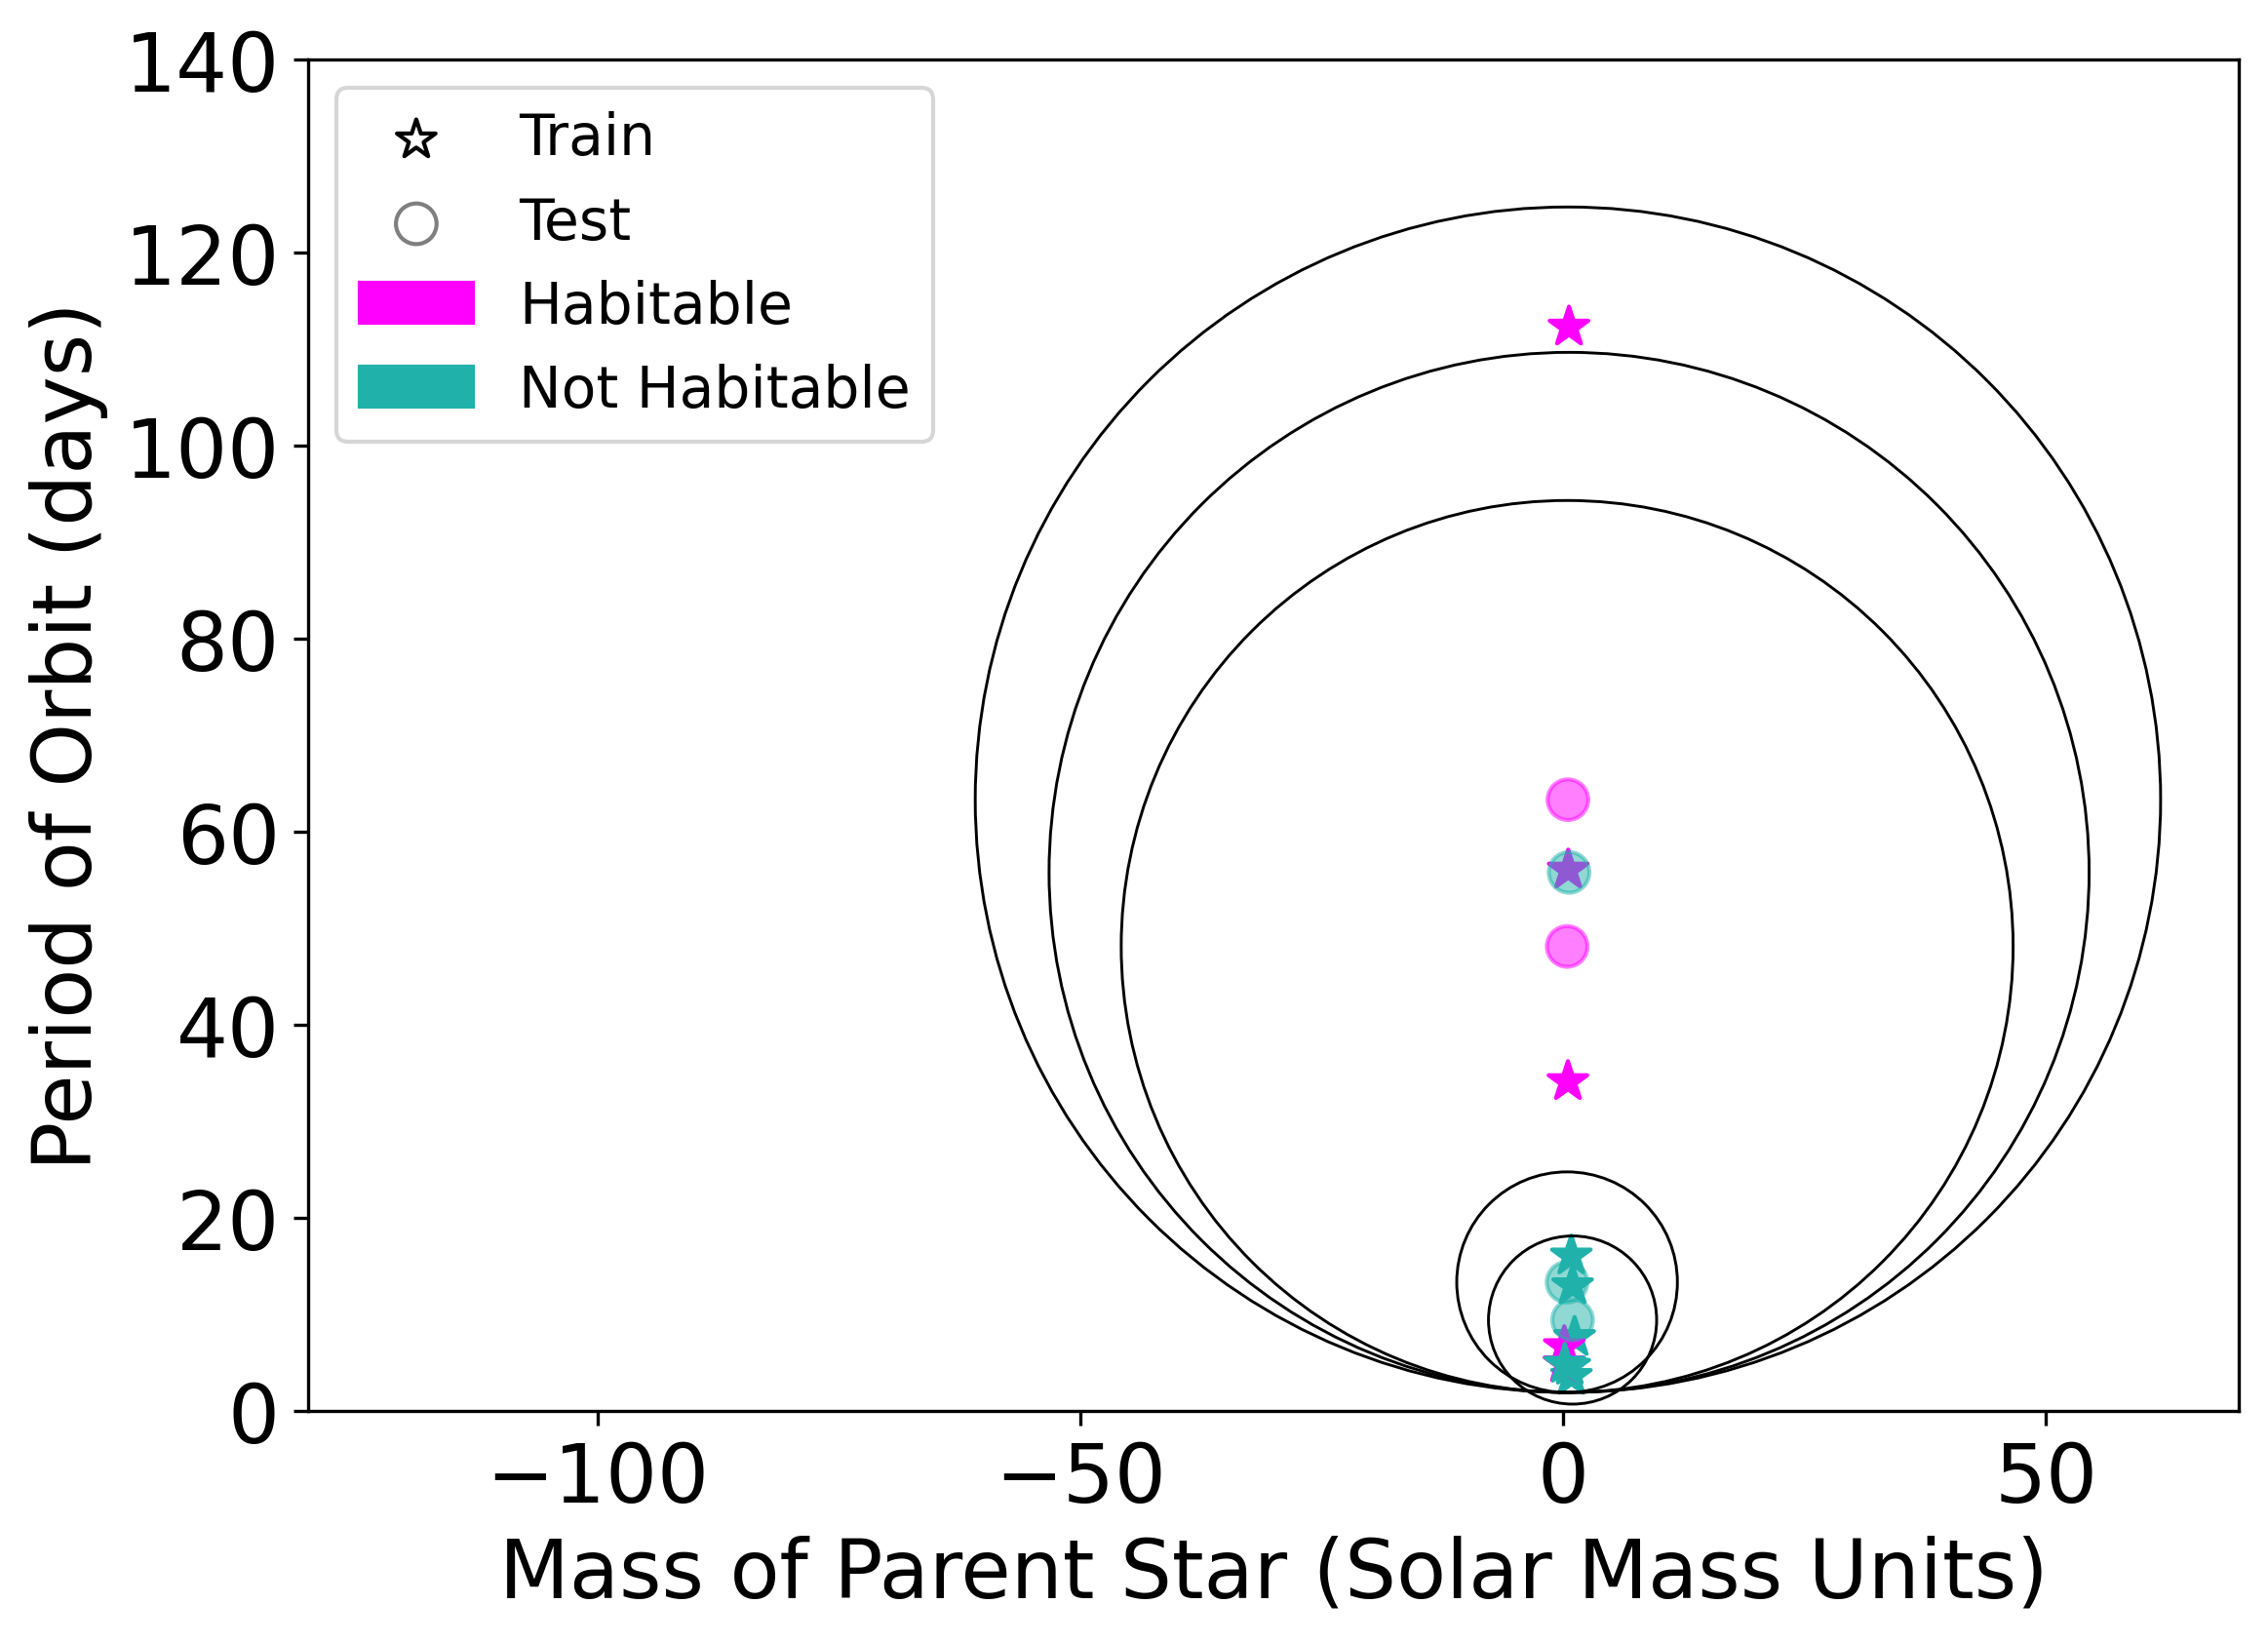

In [65]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap)

#a.set_facecolor('none')


a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5)

#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),model.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)

plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

plt.xlim(-130,70)
plt.ylim(0,140)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)')

**Repita el proceso de kNN escalado, pero usando todas las caracteristicas, y compare el accuracy**

In [75]:
model.fit(Xtrain.iloc[:,:3],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(Xtest.iloc[:,:3])

In [73]:
model.kneighbors(scaledXtest[:,:3])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


(array([[3.05646991, 3.99292867, 4.12569255],
        [3.95277715, 4.87701139, 4.95948061],
        [3.07219858, 3.95168129, 4.03629005],
        [3.67435371, 4.72878893, 4.98204787],
        [3.35633617, 4.24225661, 4.30829989]]),
 array([[ 0,  6, 12],
        [ 0,  6, 12],
        [ 0,  6, 12],
        [ 0,  6, 12],
        [ 0,  6, 12]]))

In [70]:
for i in range(len(TestSet)): # para cada elemento del set de prueba

    print(model.kneighbors(scaledXtest[:,:3])[0][i,2])

4.125692552094403
4.95948060605622
4.036290049307939
4.982047871019386
4.308299888864945


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Text(0, 0.5, 'Period of Orbit (days)')

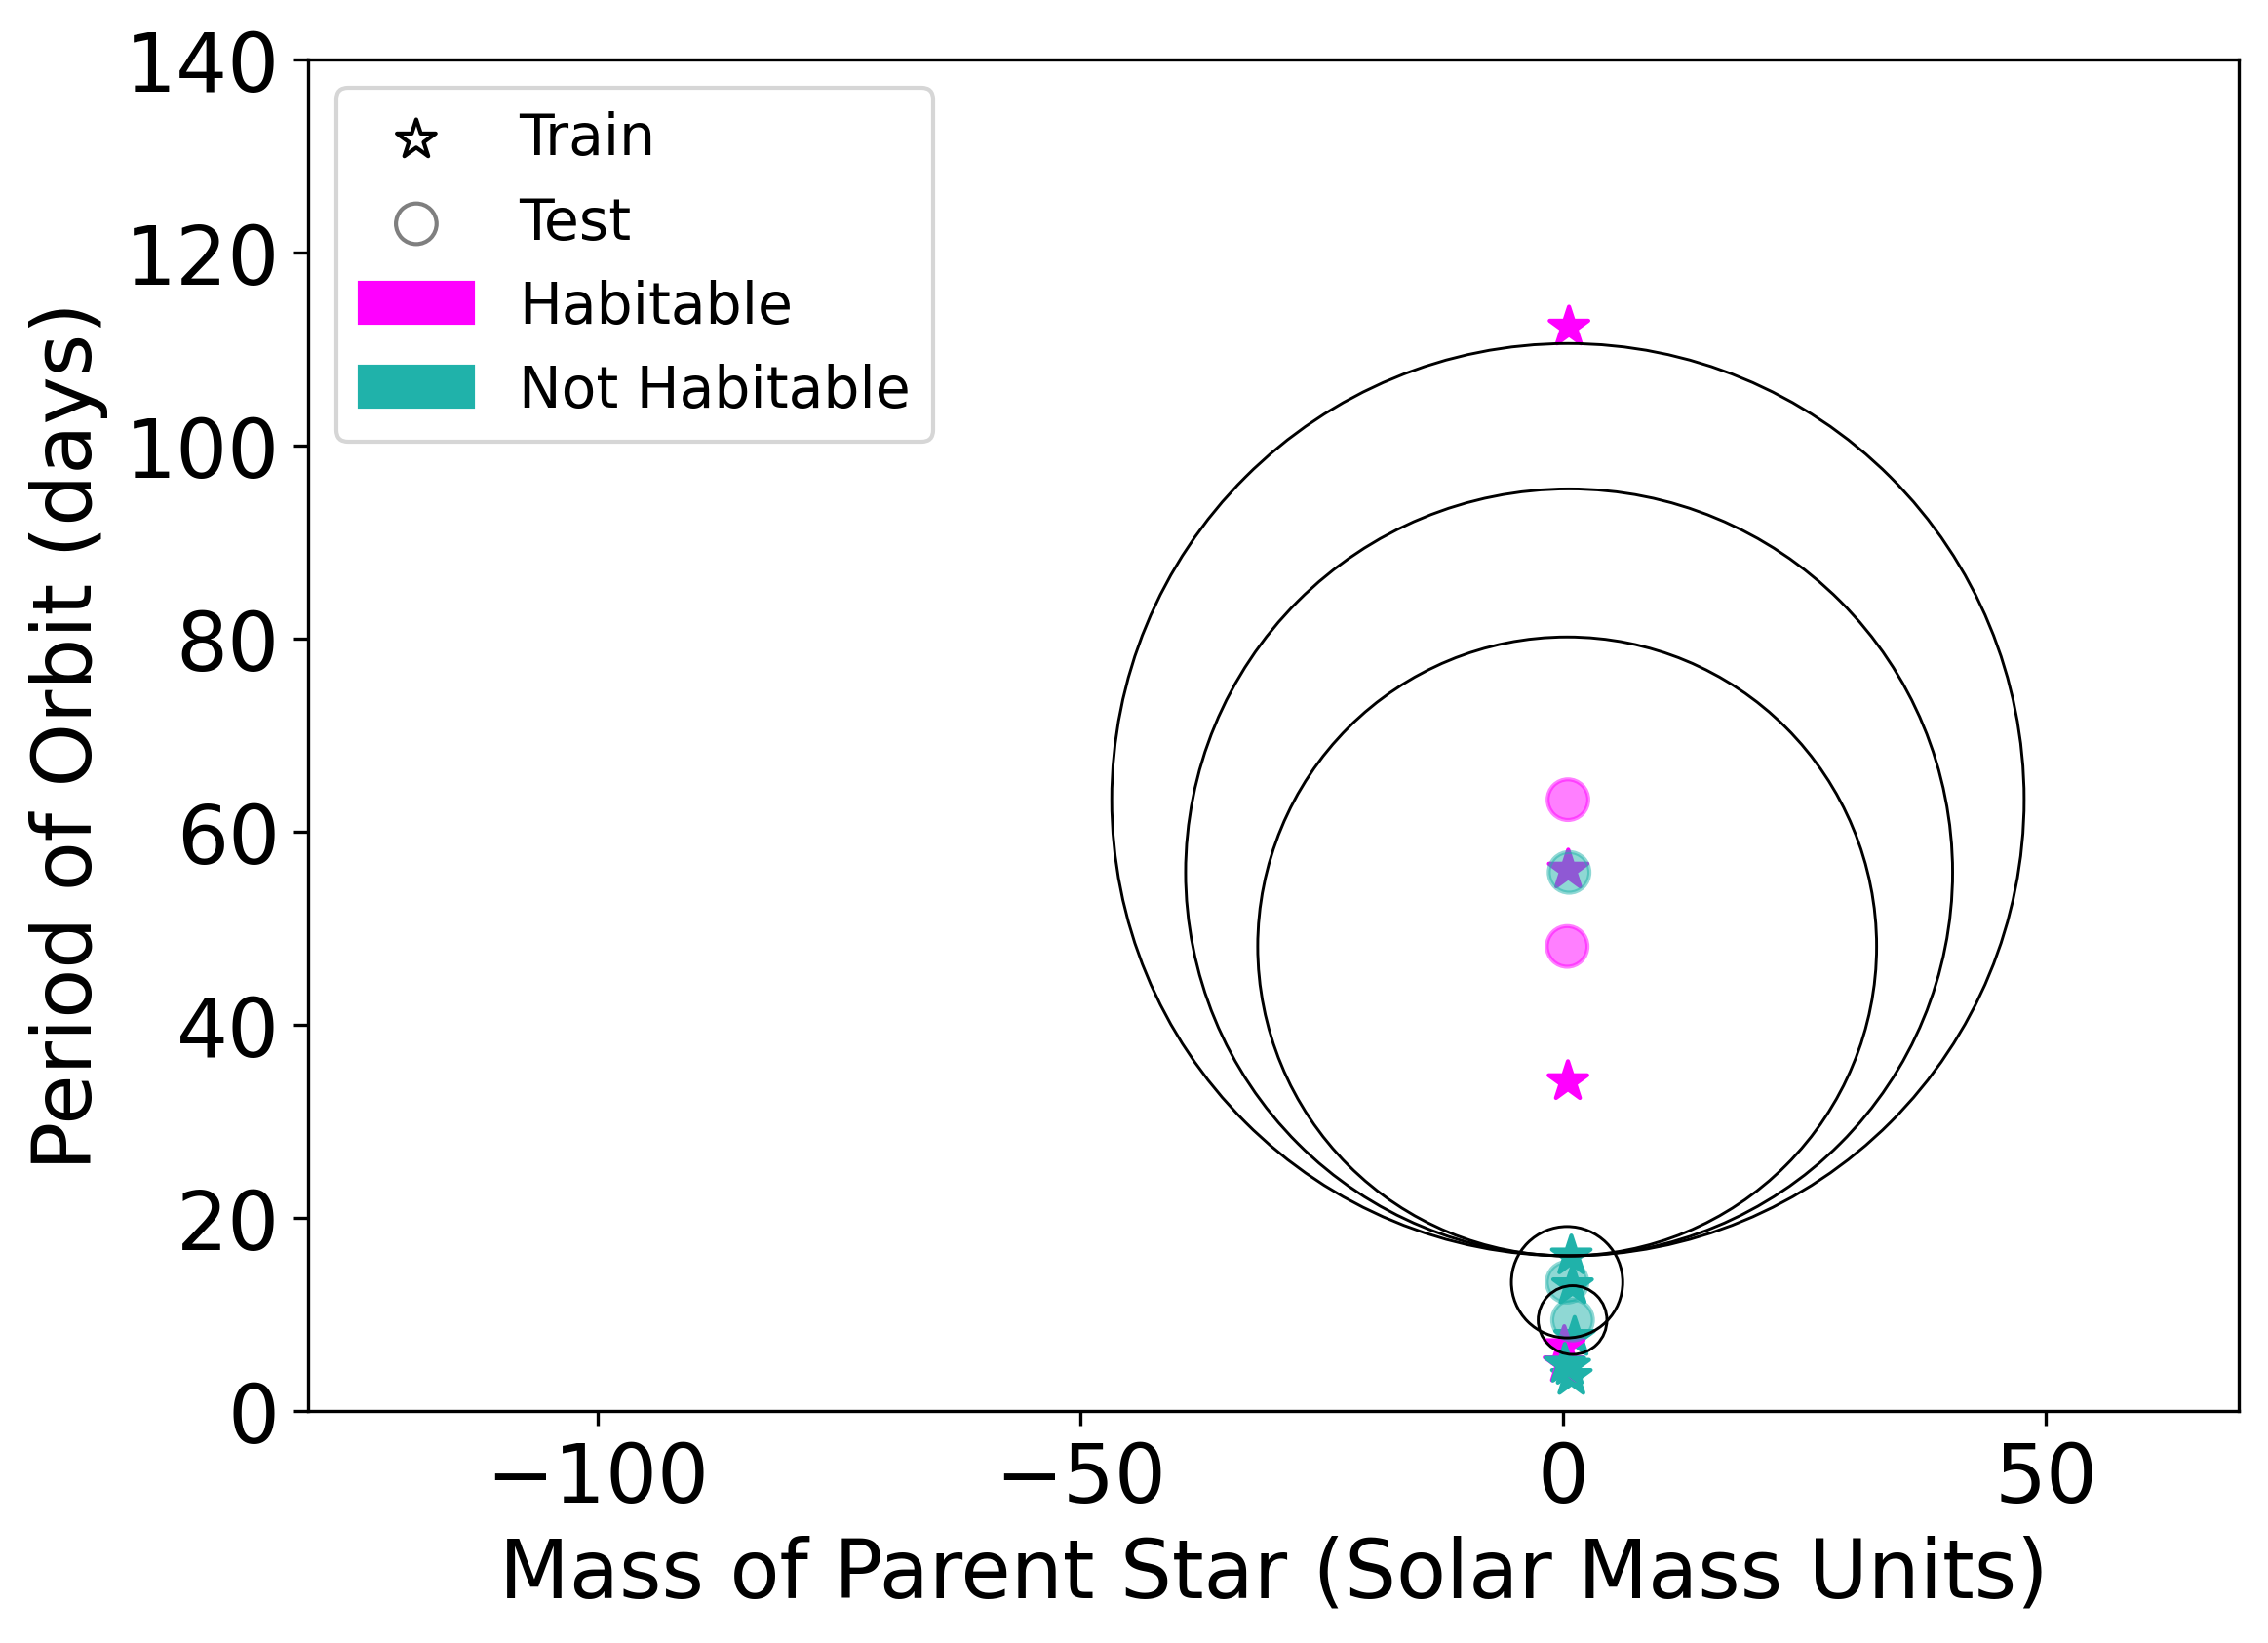

In [74]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap)

#a.set_facecolor('none')


a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5)

#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),model.kneighbors(Xtest.iloc[:,:3])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)

plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

plt.xlim(-130,70)
plt.ylim(0,140)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)')

### Preguntas

- Descubrimos que kNN necesita escalado ¿DT tiene el mismo problema?

**Respuesta:** Para los árboles de decisiones no se necesita escalar los datos.

- Compare las fortalezas y debilidades de DT y kNN

**Respuesta:** DT son más fáciles de interpretar que kNN, ya que en este último no podemos ver que "reglas" está usando. Por otro lado kNN puede adaptarse de mejor manera a nuevos datos además de necesitar pocos hiperparámetros. DT es versátil para aplicaciones de clasificación, regresión, entre otros, sin embargo, puede también presentar problemas de sobreajuste.

- ¿Qué diferencia conceptual hay entre cómo clasifica un árbol de decisión y cómo clasifica kNN?

**Respuesta:** Árbol de decisiones crea reglas explícitas y jerárquicas, mientras que kNN realiza una clasificación por consenso local.

- ¿Por qué el accuracy en entrenamiento no basta para evaluar un modelo?

**Respuesta:** Porque no mide la capacidad de generalizar a nuevos datos.

- ¿Por qué kNN requiere escalamiento y un árbol de decisión no necesariamente?

**Respuesta:** Ya que kNN trabaja con distancias necesita que los datos tengan las mismas medidas, a diferencia del árbol de decisiones que evalúa características por separado.

- Si tuvieras que elegir uno de los dos métodos para este dataset pequeño, ¿cuál elegirías y por qué?

**Respuesta:** Árbol de decisiones ya que es más sencillo de interpretar, las relaciones son más simples y no necesita un escalado de los datos


# 1. Estudiar el efecto del valor de K. Elegir distintos valores de k y graficar k vs accuracy

k =  1 | Train Accuracy: 1.0000 | Test Accuracy: 0.6000
k =  2 | Train Accuracy: 1.0000 | Test Accuracy: 0.6000
k =  3 | Train Accuracy: 0.8462 | Test Accuracy: 0.6000
k =  4 | Train Accuracy: 0.8462 | Test Accuracy: 0.8000
k =  5 | Train Accuracy: 0.8462 | Test Accuracy: 0.6000
k =  6 | Train Accuracy: 0.6923 | Test Accuracy: 0.6000
k =  7 | Train Accuracy: 0.7692 | Test Accuracy: 0.6000
k =  8 | Train Accuracy: 0.6154 | Test Accuracy: 0.6000
k =  9 | Train Accuracy: 0.7692 | Test Accuracy: 0.8000
k = 10 | Train Accuracy: 0.6923 | Test Accuracy: 0.8000
k = 11 | Train Accuracy: 0.8462 | Test Accuracy: 0.6000
Mejor K = 4 con Test Accuracy = 0.8000


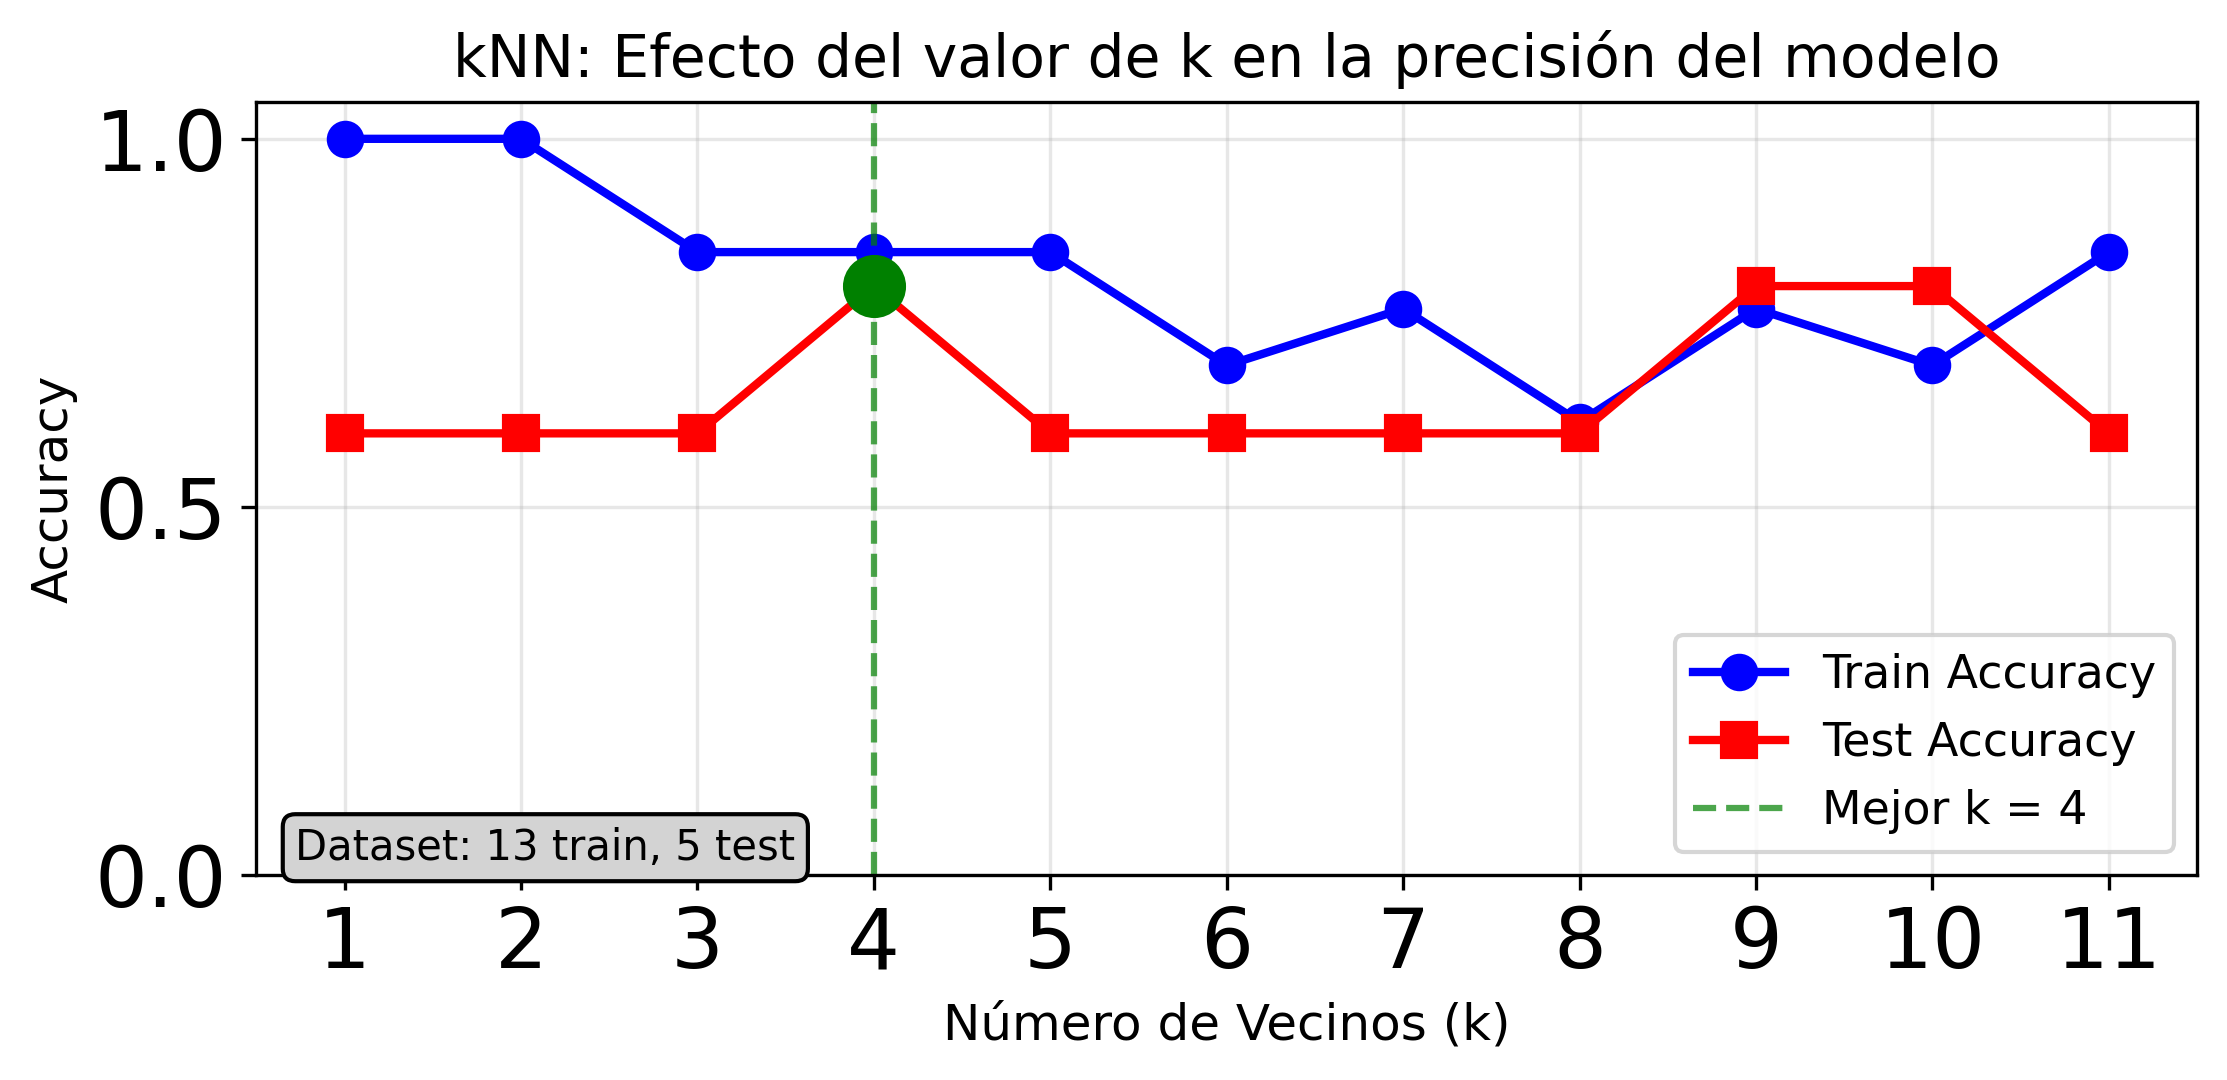

In [87]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics


ytrain = TrainSet['P_HABITABLE']
ytest = TestSet['P_HABITABLE']

feature_cols = ['S_MASS', 'P_PERIOD', 'P_DISTANCE'] # Usamos todas las columnas como en el caso anterior
Xtrain = TrainSet[feature_cols]
Xtest = TestSet[feature_cols]

scaler = StandardScaler() # Escalamos los datos, como es requerido para kNN
scaler.fit(Xtrain)
Xtrain_scaled = scaler.transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)


k_values = range(1, min(21, len(Xtrain) - 1)) # Elegimos rango de k para ejecutar

train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xtrain_scaled, ytrain)

    train_pred = knn.predict(Xtrain_scaled)
    test_pred = knn.predict(Xtest_scaled)

    train_acc = metrics.accuracy_score(ytrain, train_pred)
    test_acc = metrics.accuracy_score(ytest, test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"k = {k:2d} | Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")


best_k = k_values[np.argmax(test_accuracies)]
best_accuracy = max(test_accuracies)
print(f"Mejor K = {best_k} con Test Accuracy = {best_accuracy:.4f}")



fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(k_values, train_accuracies, 'o-', label='Train Accuracy',
         color='blue', linewidth=2, markersize=8)
ax.plot(k_values, test_accuracies, 's-', label='Test Accuracy',
         color='red', linewidth=2, markersize=8)

ax.axvline(x=best_k, color='green', linestyle='--', alpha=0.7,
            label=f'Mejor k = {best_k}')
ax.scatter(best_k, best_accuracy, color='green', s=200, zorder=5)

ax.set_xlabel('Número de Vecinos (k)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('kNN: Efecto del valor de k en la precisión del modelo', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(k_values)
ax.set_ylim(0, 1.05)

ax.text(0.02, 0.02, f'Dataset: {len(Xtrain)} train, {len(Xtest)} test',
         transform=plt.gca().transAxes, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

fig.tight_layout()
plt.show()

# 2. Explorar el efecto de hiperparámetros de un árbol. Elegir 2 hiperparámetros, cambiar valores y comparar con modelo inicial.

In [92]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

ytrain = TrainSet['P_HABITABLE']
ytest = TestSet['P_HABITABLE']
Xtrain = TrainSet[['S_MASS', 'P_PERIOD', 'P_DISTANCE']]
Xtest = TestSet[['S_MASS', 'P_PERIOD', 'P_DISTANCE']]

dt_inicial = DecisionTreeClassifier(random_state=42)
dt_inicial.fit(Xtrain, ytrain)

print("Modelo Inicial ----")
print(f"Train Accuracy: {metrics.accuracy_score(ytrain, dt_inicial.predict(Xtrain)):.4f}")
print(f"Test Accuracy: {metrics.accuracy_score(ytest, dt_inicial.predict(Xtest)):.4f}")
print(f"Profundidad: {dt_inicial.get_depth()}")

print("Profundidad máxima ----")
for depth in [2, 3, 4, 5, 6, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(Xtrain, ytrain)
    test_acc = metrics.accuracy_score(ytest, dt.predict(Xtest))
    print(f"max_depth={depth}: Test Accuracy = {test_acc:.4f}")

print("min_samples_split ----")
for min_split in [2, 3, 4, 5, 6, 7, 8]:
    dt = DecisionTreeClassifier(min_samples_split=min_split, random_state=42)
    dt.fit(Xtrain, ytrain)
    test_acc = metrics.accuracy_score(ytest, dt.predict(Xtest))
    print(f"min_samples_split={min_split}: Test Accuracy = {test_acc:.4f}")

# Pareciera que el valor del test accuracy no varía con la profundidad y son todos del mismo valor... lo cual interpreto como un error en la implementación

Modelo Inicial ----
Train Accuracy: 1.0000
Test Accuracy: 0.6000
Profundidad: 2
Profundidad máxima ----
max_depth=2: Test Accuracy = 0.6000
max_depth=3: Test Accuracy = 0.6000
max_depth=4: Test Accuracy = 0.6000
max_depth=5: Test Accuracy = 0.6000
max_depth=6: Test Accuracy = 0.6000
max_depth=None: Test Accuracy = 0.6000
min_samples_split ----
min_samples_split=2: Test Accuracy = 0.6000
min_samples_split=3: Test Accuracy = 0.6000
min_samples_split=4: Test Accuracy = 0.6000
min_samples_split=5: Test Accuracy = 0.6000
min_samples_split=6: Test Accuracy = 0.6000
min_samples_split=7: Test Accuracy = 0.6000
min_samples_split=8: Test Accuracy = 0.6000
